# Khi hệ sinh thái mất khả năng phục hồi: tái tạo Dakos et al. (2012)

Một chuỗi biomass giảm dần chưa cho biết hệ đang tiến gần tipping point hay
chỉ đang đáp ứng với harvesting tăng. Thí nghiệm này tìm dấu hiệu trong
**cách hệ dao động**: các quan sát có nhớ nhau lâu hơn không, phân bố có rộng
hơn không, và các excursions về trạng thái thấp có làm phân bố lệch đi không?

Ta đi theo mạch: **cơ chế → kiểm chứng estimator → mô phỏng → tiền xử lý →
đọc tín hiệu → thử độ nhạy → so với stationary null → đối chiếu bài báo**.
Hai kịch bản CSD và flickering cho phép thấy cùng một indicator có thể kể
những câu chuyện khác nhau. Một kết quả không khớp được giữ lại để phân tích.

Notebook này là bản tái tạo bằng **mô phỏng mới**, không phải chuỗi stochastic
gốc. Phân biệt ba mức bằng chứng: công thức tính đúng, hiện tượng định tính
khớp, và giá trị định lượng khớp. Không dùng mức thứ nhất để thay thế hai mức sau.

**Cách chạy:** chọn kernel `.venv/bin/python` rồi Run All, từ root project
hoặc `experiments/`. Theo cấu trúc project cố định, core nằm trong
`src/ews_metrics.py`, tests trong `tests/`, báo cáo ở
[`report/dakos_2012.md`](../report/dakos_2012.md), dependencies ở `requirements.txt`.
**Mọi kết quả được giữ trong RAM và hiển thị tại notebook; thí nghiệm không
xuất CSV, JSON, PNG hoặc tạo thư mục kết quả.** Có thể lưu notebook cùng
outputs hiển thị bằng chức năng Save của IDE.

## 1. Từ cơ chế đến những dấu hiệu ta kỳ vọng

Equation 8 mô tả một resource tăng trưởng logistic và bị khai thác:

$$
dx = \left[rx\left(1-\frac{x}{K}\right)
- c\frac{x^2}{x^2+h^2}\right]dt + \sigma x\,dW.
$$

Khi grazing rate $c$ tăng, nhánh equilibrium có biomass cao tiến gần fold.
Đạo hàm drift tại equilibrium tiến về 0 từ phía âm: perturbation nhỏ mất
nhiều thời gian hơn để biến mất. Đây là **critical slowing down (CSD)**.
Trong chế độ nhiễu mạnh, hệ có thể liên tục ghé các miền biomass cao/thấp,
tạo **flickering** trước khi ổn định ở trạng thái thấp.

| Kịch bản | Kỳ vọng từ cơ chế | Chi tiết cần đọc trên kết quả |
|---|---|---|
| CSD | Memory tăng: ACF và fitted AR(1) thường tăng | Sau detrending, trend có còn không? |
| CSD | Recovery chậm có thể làm variability tăng | Multiplicative noise cũng giảm khi biomass giảm; SD không tự động tăng |
| Chuyển xuống biomass thấp | Skewness có thể giảm do excursions xuống thấp | Dùng skewness có dấu; không lấy trị tuyệt đối |
| Flickering | Hai chế độ làm ACF cao và phân bố rộng | SD có thể tăng rồi giảm khi trạng thái thấp chiếm ưu thế |

Đây là kỳ vọng để kiểm tra, không phải tiêu chí để chọn seed hoặc chỉnh tham
số. Trước khi đọc dynamics, ta phải biết các estimator đang tính điều gì.

In [1]:
import importlib.metadata
import sys
import warnings
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from scipy import optimize, signal, stats
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import acf

candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next(
    path for path in candidates if (path / "src/ews_metrics.py").is_file()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
ews = importlib.import_module("src.ews_metrics")

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.2,
        "font.size": 10,
    }
)


def show_table(rows: list[dict], columns: dict[str, str]) -> None:
    """Display selected fields as an inline Markdown table."""
    lines = [
        "| "
        + " | ".join(
            heading.replace("|", r"\|") for heading in columns.values()
        )
        + " |",
        "| " + " | ".join(["---"] * len(columns)) + " |",
    ]
    for row in rows:
        values = []
        for key in columns:
            value = row.get(key)
            if isinstance(value, (float, np.floating)):
                value = f"{value:.6g}"
            elif value is None:
                value = "N/A"
            values.append(str(value).replace("|", " / ").replace("\n", " "))
        lines.append("| " + " | ".join(values) + " |")
    display(Markdown("\n".join(lines)))


versions = {"python": sys.version.split()[0]}
versions.update(
    {
        name: importlib.metadata.version(name)
        for name in ["numpy", "scipy", "matplotlib", "statsmodels", "nbformat"]
    }
)
show_table(
    [
        {"library": name, "version": version}
        for name, version in versions.items()
    ],
    {"library": "Thư viện", "version": "Phiên bản đang chạy"},
)

| Thư viện | Phiên bản đang chạy |
| --- | --- |
| python | 3.12.10 |
| numpy | 2.5.3 |
| scipy | 1.18.1 |
| matplotlib | 3.11.2 |
| statsmodels | 0.15.0 |
| nbformat | 5.11.1 |

## 2. Kiểm tra thước đo trước khi đo hệ sinh thái

Đặt $z=x-\bar x$, $m_k=\operatorname{mean}(z^k)$ và $\phi$ là fitted AR(1).
Bảng này xác định rõ quy ước; tên tương tự không có nghĩa estimator giống nhau.

| Indicator / utility | Công thức hoặc lựa chọn | Cách kiểm tra |
|---|---|---|
| ACF(1) | $\sum z_tz_{t+1}/\sum z_t^2$, common mean, biased covariance | statsmodels `acf`; tùy chọn Pearson đối chiếu NumPy |
| Fitted AR(1) | $x_{t+1}=a+\phi x_t+e_t$, conditional OLS | statsmodels `AutoReg`; exponential signal biết phi |
| Return rate | $1/\phi$ và $1-\phi$ | Cùng phi biết trước; không gọi là continuous recovery rate |
| SD | $\sqrt{\sum z_t^2/(n-1)}$, mặc định ddof=1 | NumPy; phân biệt rõ SD và variance |
| CV | SD/mean, giữ dấu mean | NumPy; zero mean không xác định |
| Skewness | $m_3/m_2^{3/2}$, signed, bias=True | SciPy; distribution bất đối xứng |
| Kurtosis | $m_4/m_2^2$, Pearson, bias=True | SciPy; Fisher tùy chọn trừ 3 |
| PSD | One-sided periodogram hoặc Welch density, mean removal | SciPy; sinusoid có frequency/power biết trước |
| Spectral ratio | $S(0.05)/S(0.5)$, point density, nội suy tuyến tính | Synthetic spectrum; kiểm tra resolved frequency range |
| Spectral exponent | $\beta=-\operatorname{slope}(\log S,\log f)$ | Power-law signal biết beta |
| Rolling / tau | Complete windows, step=1, endpoint; Kendall tau-b | Alignment, ties, overlapping windows |
| Gaussian detrending | Normalized kernel, R `ksmooth` sigma=0.3706506*bandwidth | Direct kernel weights, cả tại boundaries |

Mã R hiện tại của `generic_ews` lấy `abs(skewness)`, nhưng paper báo cáo
skewness và tau âm, còn `sensitivity_ews` giữ dấu. Ta giữ dấu. Biểu thức SD
in trong PDF thiếu căn; dùng định nghĩa SD đúng và R `sd`. Module mặc định
fit intercept cho AR(1); phần đối chiếu R sẽ dùng whole-record demeaning và
fit không intercept. ACF, Pearson và OLS không bằng nhau trong mẫu hữu hạn.

Cell sau minh họa một số kiểm tra có nghiệm/reference rõ ràng. Bộ tests đầy
đủ trong `tests/test_ews_metrics.py` kiểm tra từng metric, estimator options,
short/constant inputs, NaN/Inf và invalid domains; kết quả kiểm thử gần nhất
là **135 tests passed**. Các assertions trong notebook dừng execution nếu
một kiểm tra thất bại, không chỉ ghi nhãn “Pass”.

In [2]:
sample = np.array([1.0, 2.0, 1.5, 4.0, 3.0, 7.0, 2.5, 3.5])
fit = AutoReg(sample, lags=1, trend="c").fit()
phi, constant = ews.fit_ar1(sample)
np.testing.assert_allclose([constant, phi], fit.params, atol=1e-12)
reference_checks = [
    (
        "ACF(1)",
        ews.lag1_autocorrelation(sample),
        acf(sample, nlags=1, fft=False)[1],
    ),
    (
        "Pearson lag-1",
        ews.lag1_autocorrelation(sample, method="pearson"),
        np.corrcoef(sample[:-1], sample[1:])[0, 1],
    ),
    ("OLS AR(1)", phi, fit.params[1]),
    ("SD ddof=1", ews.standard_deviation(sample), np.std(sample, ddof=1)),
    (
        "CV",
        ews.coefficient_of_variation(sample),
        np.std(sample, ddof=1) / sample.mean(),
    ),
    ("Skewness", ews.skewness(sample), stats.skew(sample)),
    (
        "Pearson kurtosis",
        ews.kurtosis(sample),
        stats.kurtosis(sample, fisher=False),
    ),
]
validation_rows = []
for name, actual, expected in reference_checks:
    np.testing.assert_allclose(actual, expected, rtol=1e-12, atol=1e-12)
    validation_rows.append(
        {
            "metric": name,
            "actual": actual,
            "reference": expected,
            "absolute_error": abs(actual - expected),
        }
    )
known_decay = 0.7 ** np.arange(15)
np.testing.assert_allclose(ews.return_rate(known_decay), 1 / 0.7)
np.testing.assert_allclose(
    ews.return_rate(known_decay, definition="decay"), 0.3
)
sinusoid = 3 * np.sin(2 * np.pi * 0.1 * np.arange(1000))
frequency, density = ews.power_spectral_density(sinusoid)
np.testing.assert_allclose(frequency[np.argmax(density)], 0.1)
np.testing.assert_allclose(density.sum() * (frequency[1] - frequency[0]), 4.5)
show_table(
    validation_rows,
    {
        "metric": "Estimator",
        "actual": "Core module",
        "reference": "Reference",
        "absolute_error": "Sai số tuyệt đối",
    },
)

| Estimator | Core module | Reference | Sai số tuyệt đối |
| --- | --- | --- | --- |
| ACF(1) | -0.0153287 | -0.0153287 | 0 |
| Pearson lag-1 | -0.0113344 | -0.0113344 | 1.73472e-18 |
| OLS AR(1) | -0.0102041 | -0.0102041 | 3.72966e-16 |
| SD ddof=1 | 1.87916 | 1.87916 | 0 |
| CV | 0.613604 | 0.613604 | 0 |
| Skewness | 1.10444 | 1.10444 | 0 |
| Pearson kurtosis | 3.49072 | 3.49072 | 0 |

**Điều rút ra:** công thức khớp reference theo quy ước đã chọn, nhưng ACF,
Pearson và OLS cho các con số khác nhau trên cùng mẫu. Vì vậy một sai lệch với
figure trong paper cần được kiểm tra cả ở estimator lẫn mô phỏng. Ta sẽ dùng
ACF(1) cho figure chính và ghi rõ OLS ở phần mở rộng, rồi tạo hai datasets.

### 2.1. Core DFA của bạn: kiểm chứng trước khi tích hợp

**Câu hỏi:** phép chia đoạn, polynomial detrending và RMS có đúng không?
Core bạn gửi tạo profile $Y_i=\sum_{j=1}^{i}(x_j-\bar{x})$, chia thành
$M=\lfloor N/s\rfloor$ đoạn **từ đầu chuỗi, không overlap**, rồi tính

$$F(s)=\sqrt{\frac{1}{Ms}\sum_{\nu=1}^{M}\sum_{i=1}^{s}
       [Y_{\nu,i}-p_{\nu,m}(i)]^2},\qquad F(s)\propto s^\alpha.$$

Phần đuôi thiếu một đoạn bị bỏ riêng tại mỗi scale. Lệnh `polyval` dùng
trục cột của bạn broadcast đúng với các hệ số từ `polyfit`.
Module dùng QR trên trục local đã scale để fit cùng không gian polynomial;
không đổi công thức. Dưới đây kiểm tra bằng đúng phép polyfit của bạn,
nghiệm giải tích và hai tín hiệu tham chiếu độc lập.

**Những sửa đổi cần thiết:** sửa typo `mport`; từ chối scale phân số,
NaN/Inf và fit thiếu ít nhất ba scales phân biệt; không âm thầm bỏ F lỗi.
Scales được sort/deduplicate. Constant hoặc trend đã loại hết trả F=0,
nhưng alpha không xác định thì raise `ValueError`. Mặc định một box/scale
để giữ convention của bạn; các thực nghiệm dùng `min_segments=2`.
Residual dưới ngưỡng relative floating-point precision được xem là zero.

Không tích hợp `interpret_alpha` và `detect_crossover`: thứ tự các nhánh
alpha trong script có lỗi; fit hai phía dùng chung một điểm chưa ép hai
đường liên tục; gain R² là heuristic chưa có kiểm định. Một slope trên dải
hữu hạn không đủ chứng minh long-range correlation hay bifurcation.
Plotting nằm trong notebook.

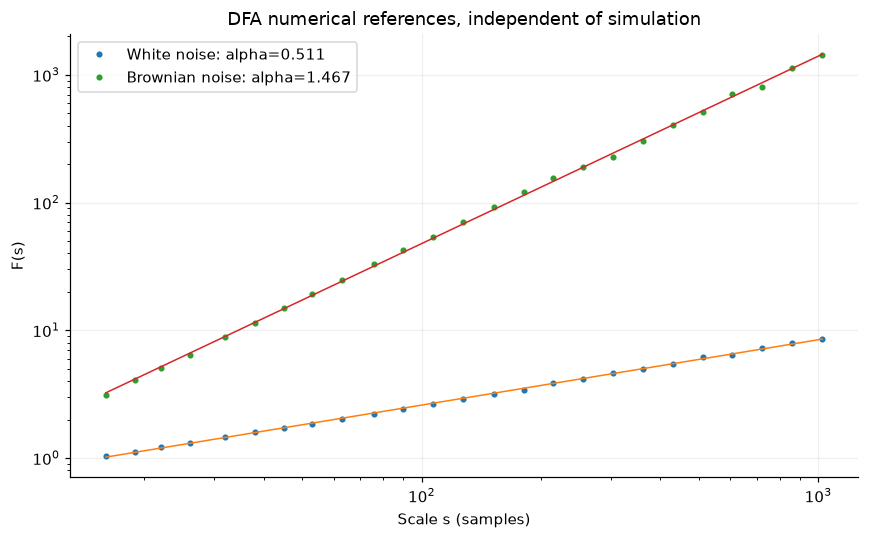

| Validation | Max \|F - reference\| | Raw alpha | Log-log R² |
| --- | --- | --- | --- |
| User polyfit, order=0 | 2.22045e-16 | N/A | N/A |
| User polyfit, order=1 | 8.88178e-16 | N/A | N/A |
| User polyfit, order=2 | 4.44089e-16 | N/A | N/A |
| User polyfit, order=3 | 2.22045e-16 | N/A | N/A |
| Linear input, analytic DFA1 RMS | 4.85034e-12 | N/A | N/A |
| White noise: expected alpha=0.5 | N/A | 0.511478 | 0.99943 |
| Brownian noise: expected alpha=1.5 | N/A | 1.46707 | 0.999604 |

In [3]:
dfa_validation_rows = []
audit_signal = np.random.default_rng(19).normal(size=997)
audit_scales = np.array([10, 15, 23, 50, 100])
for order in range(4):
    profile = np.cumsum(audit_signal - audit_signal.mean())
    reference_f = []
    for scale in audit_scales:
        boxes = profile[: profile.size // scale * scale].reshape(-1, scale)
        axis = np.arange(scale)
        coefficients = np.polyfit(axis, boxes.T, order)
        residual = boxes - np.polyval(coefficients, axis[:, None]).T
        reference_f.append(np.sqrt(np.mean(residual**2)))
    _, core_f = ews.compute_dfa_core(audit_signal, audit_scales, order)
    np.testing.assert_allclose(core_f, reference_f, rtol=1e-11, atol=1e-11)
    dfa_validation_rows.append(
        {
            "check": f"User polyfit, order={order}",
            "max_error": float(np.max(np.abs(core_f - reference_f))),
            "alpha": None,
            "r2": None,
        }
    )
analytic_scales = np.array([10, 20, 50, 100, 200])
_, analytic_f = ews.compute_dfa_core(np.arange(1000.0), analytic_scales)
expected_f = np.sqrt((analytic_scales**2 - 1) * (analytic_scales**2 - 4) / 720)
np.testing.assert_allclose(analytic_f, expected_f, rtol=1e-11, atol=1e-10)
dfa_validation_rows.append(
    {
        "check": "Linear input, analytic DFA1 RMS",
        "max_error": float(np.max(np.abs(analytic_f - expected_f))),
        "alpha": None,
        "r2": None,
    }
)
reference_rng = np.random.default_rng(42)
reference_signals = {
    "White noise": reference_rng.normal(size=65_536),
    "Brownian noise": np.cumsum(reference_rng.normal(size=65_536)),
}
reference_scales = np.unique(np.geomspace(16, 1024, 25).astype(int))
figure, axis = plt.subplots(figsize=(8, 5))
for name, reference_signal in reference_signals.items():
    expected_alpha = 0.5 if name == "White noise" else 1.5
    result = ews.dfa(reference_signal, reference_scales, min_segments=2)
    alpha = result["global_alpha"]
    assert abs(alpha - expected_alpha) < 0.08
    assert result["global_R2"] > 0.995
    dfa_validation_rows.append(
        {
            "check": f"{name}: expected alpha={expected_alpha}",
            "max_error": None,
            "alpha": alpha,
            "r2": result["global_R2"],
        }
    )
    axis.loglog(
        result["scales"],
        result["fluctuations"],
        "o",
        ms=3,
        label=f"{name}: alpha={alpha:.3f}",
    )
    axis.loglog(
        result["scales"],
        10 ** result["global_intercept"] * result["scales"] ** alpha,
        lw=1,
    )
axis.set(
    xlabel="Scale s (samples)",
    ylabel="F(s)",
    title="DFA numerical references, independent of simulation",
)
axis.legend()
figure.tight_layout()
plt.show()
plt.close(figure)
show_table(
    dfa_validation_rows,
    {
        "check": "Validation",
        "max_error": "Max |F - reference|",
        "alpha": "Raw alpha",
        "r2": "Log-log R²",
    },
)

**Điều đã xác nhận:** core của bạn tính đúng F(s), kể cả khi độ dài không
chia hết cho scale. Với input $x_i=i$, DFA1 có nghiệm
$F(s)=\sqrt{(s^2-1)(s^2-4)/720}$; DFA2 loại được linear trend của input.
DFA1 chỉ loại polynomial bậc 1 của **profile**, tương đương constant trend
của input, nên bước linear detrending input trong Figure 3 vẫn cần thiết.

White noise có alpha gần 0.5, random walk gần 1.5 trong thí nghiệm dài này.
Đây là checks với sampling tolerance, không phải bộ phân loại mọi dữ liệu.
Scales 16–1.024 ở đây kiểm tra estimator; Figure 3 bên dưới dùng 10–100.
Giờ có thể dùng core đã kiểm chứng trên cùng ecological realizations.

## 3. Dựng hai con đường tới chuyển trạng thái

Ta giữ những thông số paper công bố và ghi riêng những lựa chọn chưa đủ
thông tin để khôi phục. Dùng seed cố định từ đầu; không tìm realization có
đồ thị hoặc tau đẹp hơn.

| Thành phần | Paper / lựa chọn của notebook |
|---|---|
| Logistic / harvesting | r=1, K=10, h=1; c tăng tuyến tính từ 1 đến 2.6771 |
| CSD | 1.000 observations, sigma=0.03, seed=2012 |
| Flickering | 10.000 observations, sigma=0.15, seed=2013 |
| Measurement noise | Gaussian SD=0.1, thêm sau integration, không clip observed data |
| Integration được chọn | Itô Euler–Maruyama, dt=0.1, sampling interval=1; c giữ cố định mỗi interval |
| Initial condition được chọn | Equilibrium cao tại c=1; red-noise state q=0; first observation sau interval đầu |
| Boundary được chọn | Project biomass lên [0, infinity) nếu Euler step âm; đếm projections |

Process, red-noise và measurement dùng ba streams độc lập từ SeedSequence.
Việc đổi dt không làm đổi measurement stream, nhưng **không** tạo cùng một
Brownian path ở các dt; kiểm tra refinement dưới đây chỉ dùng deterministic drift.

**Điểm cần phân biệt ở flickering.** Paper in recurrence
`i[t+1]=(0.95*i[t]+0.07*eta[t])*x[t]`, với T=20, beta=0.07 và eta~N(0,1).
Nếu inflow i được giữ trực tiếp qua các bước, memory coefficient `0.95*x`
lớn hơn 1 ở nhánh cao. Notebook diễn giải biến nhớ là nhiễu không thứ nguyên
`q[t+1]=0.95*q[t]+0.07*eta[t]`, rồi thêm inflow `q*x` vào drift. q cập nhật
mỗi observation và giữ trong substeps. Đây là **khác biệt mô hình được công
bố**, không xác nhận paper có lỗi và không phải replication chính xác của GRIND.

In [4]:
def resource_drift(
    x: float,
    grazing: float,
    r: float = 1.0,
    carrying_capacity: float = 10.0,
    h: float = 1.0,
) -> float:
    """Return r*x*(1-x/K) - c*x**2/(x**2+h**2)."""
    growth = r * x * (1 - x / carrying_capacity)
    harvest = grazing * x**2 / (x**2 + h**2)
    return growth - harvest


def drift_derivative(x: float, grazing: float) -> float:
    """Return df/dx for r=h=1 and K=10."""
    return 1 - x / 5 - 2 * grazing * x / (1 + x**2) ** 2


def positive_equilibria(grazing: float) -> np.ndarray:
    """Return positive real roots of the equilibrium cubic."""
    roots = np.roots([-0.1, 1, -(0.1 + grazing), 1])
    selected = roots[(np.abs(roots.imag) < 1e-09) & (roots.real > 0)]
    return np.sort(selected.real)


def simulate_resource(
    n_observations: int,
    sigma: float,
    seed: int,
    *,
    dt: float = 0.1,
    red_noise: bool = False,
    measurement_sd: float = 0.1,
) -> dict:
    """Integrate Equation 8 with Itô noise and optional q*x inflow."""
    substeps = round(1 / dt)
    if dt <= 0 or not np.isclose(substeps * dt, 1):
        raise ValueError("dt must divide the unit sampling interval")
    streams = np.random.SeedSequence(seed).spawn(3)
    process_rng, red_rng, measurement_rng = [
        np.random.default_rng(stream) for stream in streams
    ]
    grazing = np.linspace(1, 2.6771, n_observations)
    biomass = np.empty(n_observations)
    red_state = np.empty(n_observations)
    x = float(positive_equilibria(1)[-1])
    q = 0.0
    projections = 0
    process_noise = process_rng.normal(size=(n_observations, substeps))
    red_innovations = red_rng.normal(size=n_observations)
    for index, c in enumerate(grazing):
        if red_noise:
            q = 0.95 * q + 0.07 * red_innovations[index]
        for substep in range(substeps):
            deterministic = resource_drift(x, c) + q * x
            random_increment = sigma * x * np.sqrt(dt)
            candidate = (
                x
                + deterministic * dt
                + random_increment * process_noise[index, substep]
            )
            projections += int(candidate < 0)
            x = max(0.0, candidate)
        biomass[index] = x
        red_state[index] = q
    observed = biomass + measurement_rng.normal(
        0, measurement_sd, n_observations
    )
    return {
        "time": np.arange(1, n_observations + 1),
        "grazing": grazing,
        "biomass": biomass,
        "observed": observed,
        "red_state": red_state,
        "projections": projections,
        "seed": seed,
        "dt": dt,
    }

In [5]:
fold = optimize.root(
    lambda pair: [
        resource_drift(pair[0], pair[1]),
        drift_derivative(pair[0], pair[1]),
    ],
    [4.8, 2.6],
)
assert fold.success
fold_biomass, fold_grazing = fold.x
assert abs(fold_grazing - 2.604) < 0.001
assert len(positive_equilibria(2)) == 3
for equilibrium in positive_equilibria(2):
    assert abs(resource_drift(equilibrium, 2)) < 1e-10
csd = simulate_resource(1000, 0.03, 2012)
flickering = simulate_resource(10000, 0.15, 2013, red_noise=True)
repeated = simulate_resource(1000, 0.03, 2012)
np.testing.assert_array_equal(csd["observed"], repeated["observed"])
assert csd["biomass"][:500].mean() > 5
assert csd["biomass"][-1] < 1
assert np.count_nonzero(np.diff(flickering["biomass"] < 2)) > 2
assert np.any(flickering["biomass"][5000:] > 5)
assert np.any(flickering["biomass"][5000:] < 1)
simulation_rows = []
for name, data in [("CSD", csd), ("Flickering", flickering)]:
    low_state = data["biomass"] < 2
    first_low = np.flatnonzero(low_state)
    simulation_rows.append(
        {
            "scenario": name,
            "seed": data["seed"],
            "dt": data["dt"],
            "first_biomass_below_2": int(data["time"][first_low[0]])
            if first_low.size
            else None,
            "crossings_biomass_2": int(np.count_nonzero(np.diff(low_state))),
            "minimum_biomass": float(data["biomass"].min()),
            "last_biomass": float(data["biomass"][-1]),
            "boundary_projections": data["projections"],
        }
    )
    assert np.all(np.isfinite(data["observed"]))
    assert np.all(data["biomass"] >= 0)

show_table(
    simulation_rows,
    {
        "scenario": "Scenario",
        "seed": "Seed",
        "first_biomass_below_2": "Lần đầu biomass <2",
        "crossings_biomass_2": "Crossings threshold 2",
        "last_biomass": "Biomass cuối",
        "boundary_projections": "Projections",
    },
)
display(
    Markdown(
        f"Fold deterministic: **c={fold_grazing:.6f}**, "
        f"x={fold_biomass:.6f}. Memory coefficient nếu đọc literal "
        f"red recurrence tại equilibrium đầu: "
        f"**{0.95 * positive_equilibria(1)[-1]:.3f}**."
    )
)

| Scenario | Seed | Lần đầu biomass <2 | Crossings threshold 2 | Biomass cuối | Projections |
| --- | --- | --- | --- | --- | --- |
| CSD | 2012 | 978 | 1 | 0.417489 | 0 |
| Flickering | 2013 | 204 | 69 | 0.50487 | 0 |

Fold deterministic: **c=2.604365**, x=4.781284. Memory coefficient nếu đọc literal red recurrence tại equilibrium đầu: **8.445**.

### Đọc Figure 1: hai paths có thể trông khác nhau như thế nào?

Panel equilibrium dùng màu xanh cho stable branch, cam cho unstable branch;
điểm đen đánh dấu fold trên nhánh cao. Hai panel còn lại đặt biomass cạnh
forcing c để thấy transition không cần forcing nhảy đột ngột. Threshold
biomass=2 ở bảng chỉ là diagnostic, không phải basin boundary được suy ra.

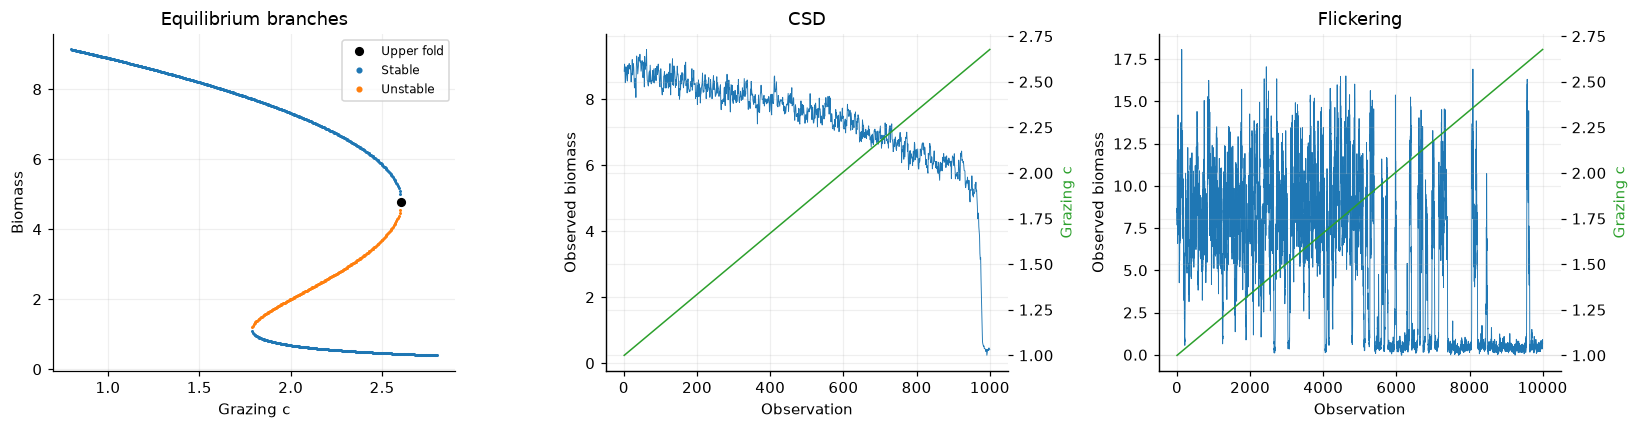

In [6]:
figure, axes = plt.subplots(1, 3, figsize=(15, 4))
for c in np.linspace(0.8, 2.8, 450):
    for equilibrium in positive_equilibria(c):
        stable = drift_derivative(equilibrium, c) < 0
        axes[0].plot(
            c,
            equilibrium,
            ".",
            ms=2,
            color="tab:blue" if stable else "tab:orange",
        )

axes[0].plot(fold_grazing, fold_biomass, "ko", ms=5, label="Upper fold")
axes[0].plot([], [], ".", color="tab:blue", label="Stable")
axes[0].plot([], [], ".", color="tab:orange", label="Unstable")
axes[0].legend(fontsize=8)

axes[0].set(xlabel="Grazing c", ylabel="Biomass", title="Equilibrium branches")
for axis, name, data in zip(
    axes[1:], ["CSD", "Flickering"], [csd, flickering]
):
    axis.plot(data["time"], data["observed"], lw=0.6, color="tab:blue")
    axis.set(xlabel="Observation", ylabel="Observed biomass", title=name)
    second = axis.twinx()
    second.plot(data["time"], data["grazing"], color="tab:green", lw=1)
    second.set_ylabel("Grazing c", color="tab:green")
figure.tight_layout()
plt.show()
plt.close(figure)

**Điều rút ra:** CSD rời nhánh biomass cao rồi sụp xuống; flickering có nhiều
excursions và những đoạn dài ở mức thấp/cao. Dynamics định tính xuất hiện,
nhưng thời điểm excursion đầu và recurrence của noise khác dữ liệu gốc.
Ta chưa thể gọi đây là quantitative reproduction. Trước khi tính EWS,
ta kiểm tra integration và xác định phần dữ liệu sẽ phân tích.

## 4. Kiểm tra bước tích phân trước khi diễn giải các dao động

Cùng deterministic forcing, tính lại bằng dt=0.1, 0.05 và 0.025, không process
noise và không measurement noise. Nếu bước nhỏ hơn tiến gần hơn đến reference
0.025, ta có một kiểm tra refinement hữu ích. dt=0.025 vẫn là numerical
reference, không phải nghiệm chính xác; kiểm tra này không chứng minh strong
convergence của stochastic simulation hoặc khớp solver GRIND của paper.

In [7]:
deterministic = [
    simulate_resource(1000, 0, 2012, dt=step, measurement_sd=0)
    for step in [0.1, 0.05, 0.025]
]
error_coarse = np.max(
    np.abs(deterministic[0]["biomass"] - deterministic[2]["biomass"])
)
error_fine = np.max(
    np.abs(deterministic[1]["biomass"] - deterministic[2]["biomass"])
)
assert error_fine < error_coarse
integration_summary = {
    "max_error_dt_0.1_vs_0.025": float(error_coarse),
    "max_error_dt_0.05_vs_0.025": float(error_fine),
}

show_table(
    [
        {"dt": 0.1, "reference_dt": 0.025, "max_error": error_coarse},
        {"dt": 0.05, "reference_dt": 0.025, "max_error": error_fine},
    ],
    {"dt": "dt", "reference_dt": "Reference dt", "max_error": "Max error"},
)

| dt | Reference dt | Max error |
| --- | --- | --- |
| 0.1 | 0.025 | 0.0407919 |
| 0.05 | 0.025 | 0.0135511 |

**Điều rút ra:** error giảm khi giảm timestep trong deterministic check.
Vì không có solver settings và stochastic path gốc, sai lệch về simulation
vẫn là một giới hạn cần giữ khi đối chiếu figures. Bước tiếp theo là tách
trend biomass khỏi những dao động mà EWS cần đo.

## 5. Chuẩn bị dữ liệu: điều gì được loại đi, điều gì phải giữ lại?

Raw CSD có mean giảm theo harvesting; trend này tự tạo correlation và
variability trong cửa sổ. Ta giữ 970 observations đầu như paper, trừ Gaussian
trend với bandwidth=97 (10% record), rồi phân tích residual. Gaussian
`ksmooth` dùng sigma=0.3706506*97, cutoff=4 sigma, normalize các weights
còn có tại biên; bandwidth không phải sigma trực tiếp.

Flickering dùng toàn bộ 10.000 observations vì transition khó xác định.
Ta dùng log(z+1), sau đó standardize bằng sample SD để giảm ảnh hưởng scale.
Đây không phải Gaussian detrending: những đoạn thuộc hai chế độ vẫn cần xuất
hiện trong transformed record để nghiên cứu flickering.

**Cách đọc figure:** CSD raw/trend ở trên và residual ở dưới; flickering raw
ở trên và standardized log ở dưới. Quan sát cấu trúc còn lại trước khi đọc
indicator. Cutoff 970 giữ cố định; collapse thực tế của realization được báo
riêng. Gaussian smoothing hai phía dùng observations tương lai; endpoint
alignment của windows không làm preprocessing này causal.

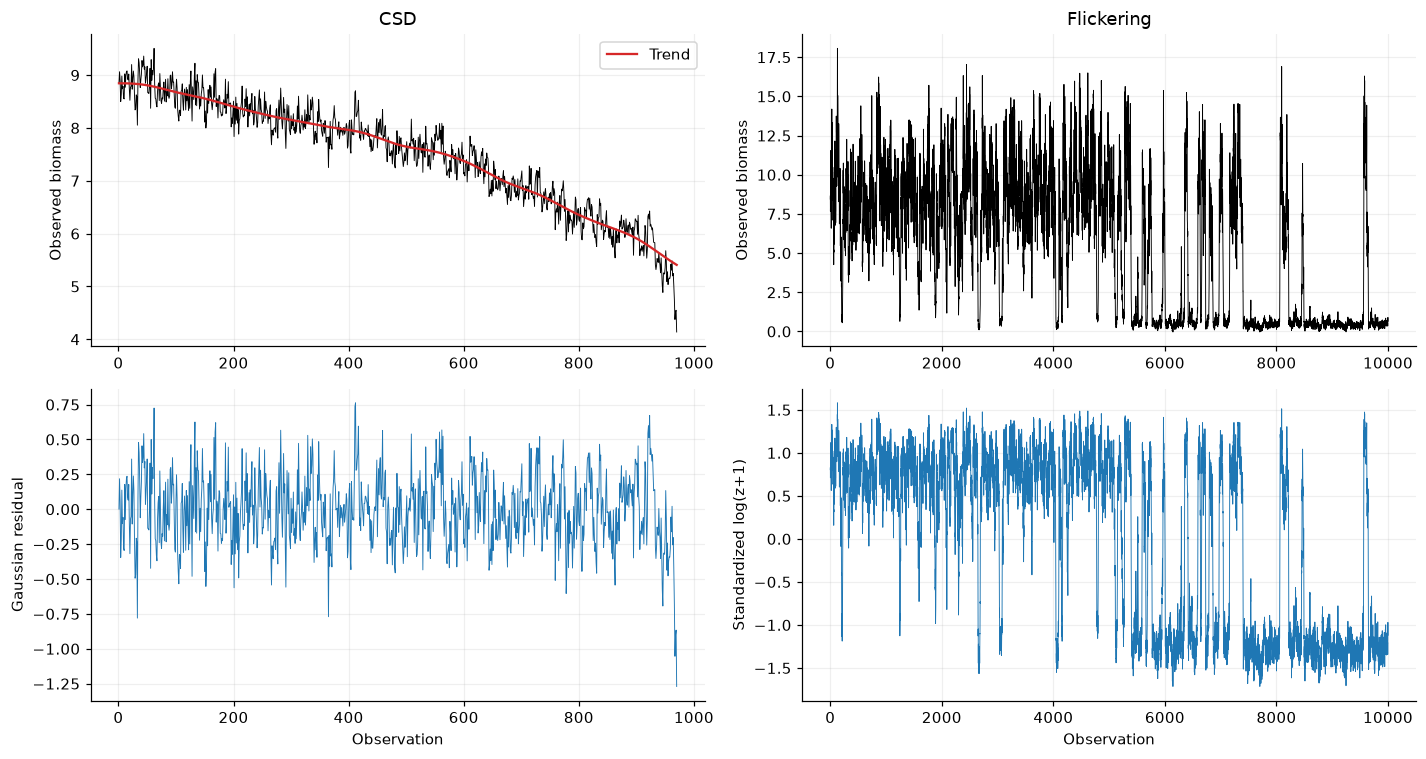

| Scenario | Độ dài phân tích | Window | Processed mean | Processed SD |
| --- | --- | --- | --- | --- |
| CSD | 970 | 485 | -0.00411272 | 0.252799 |
| Flickering | 10000 | 5000 | 9.09495e-17 | 1 |

In [8]:
raw_csd = csd["observed"][:970]
residual_csd, trend_csd = ews.gaussian_detrend(raw_csd, 97)
raw_flickering = flickering["observed"]
transformed_flickering = ews.standardize(ews.log_transform(raw_flickering))
records = {
    "CSD": {"raw": raw_csd, "processed": residual_csd, "window": 485},
    "Flickering": {
        "raw": raw_flickering,
        "processed": transformed_flickering,
        "window": 5000,
    },
}
figure, axes = plt.subplots(2, 2, figsize=(13, 7))
for column, (scenario, record) in enumerate(records.items()):
    time = np.arange(1, record["raw"].size + 1)
    axes[0, column].plot(time, record["raw"], color="black", lw=0.6)
    if scenario == "CSD":
        axes[0, column].plot(time, trend_csd, color="tab:red", label="Trend")
        axes[0, column].legend()
    axes[0, column].set(title=scenario, ylabel="Observed biomass")
    axes[1, column].plot(time, record["processed"], lw=0.6)
    axes[1, column].set(
        xlabel="Observation",
        ylabel="Gaussian residual"
        if scenario == "CSD"
        else "Standardized log(z+1)",
    )
figure.tight_layout()
plt.show()
plt.close(figure)
show_table(
    [
        {
            "scenario": name,
            "length": record["raw"].size,
            "window": record["window"],
            "mean": float(record["processed"].mean()),
            "sd": float(np.std(record["processed"], ddof=1)),
        }
        for name, record in records.items()
    ],
    {
        "scenario": "Scenario",
        "length": "Độ dài phân tích",
        "window": "Window",
        "mean": "Processed mean",
        "sd": "Processed SD",
    },
)

**Điều rút ra:** residual CSD tập trung quanh local trend, còn flickering
vẫn có hai chế độ sau transformation. Toàn bộ residual không bắt buộc có
mean đúng bằng 0 do boundary normalization; standardized flickering có mean
0 và sample SD 1. Ta sẽ đọc raw và processed song song để thấy preprocessing
ảnh hưởng đến kết luận ra sao.

## 6. Từ record sang tín hiệu: Figure 2

Mỗi window chiếm 50% record: 485 điểm cho CSD, 5.000 cho flickering.
Window dịch 1 observation, và metric gán vào endpoint: vị trí đầu tiên
trên figure là observation 485 hoặc 5.000. Code dùng zero-based positions,
cộng 1 khi vẽ. Không smoothing metric trajectory sau khi tính.

Ba hàng là ACF(1), SD và signed skewness; đen là raw, xanh là processed.
Kendall tau-b đo direction trên **toàn trajectory**, không chỉ chênh lệch
đầu/cuối. Một đường tăng rồi giảm có thể cho tau dương; một đường có endpoint
cuối cao hơn đầu vẫn có thể có tau âm. Overlapping windows phụ thuộc nhau,
nên tau chỉ là descriptive trend ở bước này, không là significance test.

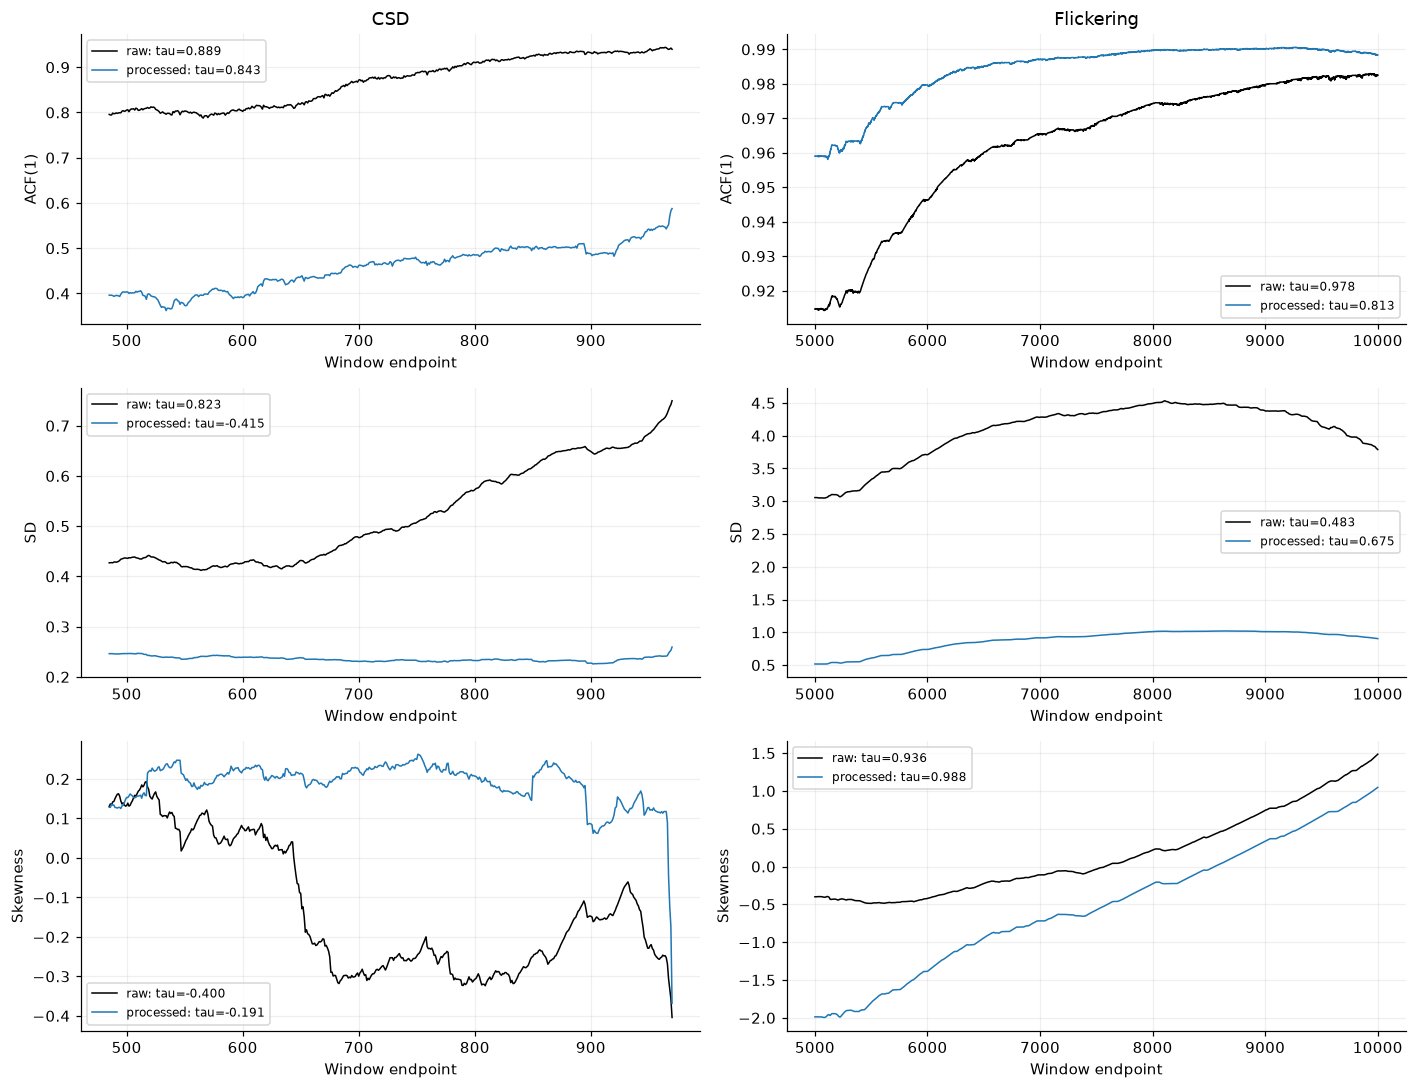

| Scenario | Dữ liệu | Indicator | Tau-b | Giá trị đầu | Giá trị cuối | Peak endpoint |
| --- | --- | --- | --- | --- | --- | --- |
| CSD | raw | ACF(1) | 0.888728 | 0.795662 | 0.939699 | 964 |
| CSD | processed | ACF(1) | 0.842892 | 0.396251 | 0.587613 | 970 |
| CSD | raw | SD | 0.822867 | 0.427019 | 0.749721 | 970 |
| CSD | processed | SD | -0.415366 | 0.246143 | 0.259283 | 970 |
| CSD | raw | Skewness | -0.399856 | 0.130767 | -0.404108 | 517 |
| CSD | processed | Skewness | -0.190785 | 0.128451 | -0.368473 | 751 |
| Flickering | raw | ACF(1) | 0.978011 | 0.914677 | 0.982519 | 9930 |
| Flickering | processed | ACF(1) | 0.81272 | 0.959011 | 0.988389 | 9270 |
| Flickering | raw | SD | 0.482806 | 3.05577 | 3.78833 | 8109 |
| Flickering | processed | SD | 0.67514 | 0.516468 | 0.903229 | 8630 |
| Flickering | raw | Skewness | 0.936141 | -0.399341 | 1.4853 | 10000 |
| Flickering | processed | Skewness | 0.987923 | -1.98684 | 1.04674 | 10000 |

In [9]:
PRIMARY_METRICS = {
    "ACF(1)": ews.lag1_autocorrelation,
    "SD": ews.standard_deviation,
    "Skewness": ews.skewness,
}
trajectories = {}
trend_rows = []
figure, axes = plt.subplots(3, 2, figsize=(13, 10))
for column, (scenario, record) in enumerate(records.items()):
    for row, (metric_name, metric) in enumerate(PRIMARY_METRICS.items()):
        for kind, color in [("raw", "black"), ("processed", "tab:blue")]:
            values, positions = ews.rolling_metric(
                record[kind], metric, record["window"]
            )
            tau = ews.kendall_tau(values, positions)
            trajectories[(scenario, kind, metric_name)] = (values, positions)
            trend_rows.append(
                {
                    "scenario": scenario,
                    "preprocessing": kind,
                    "metric": metric_name,
                    "tau": tau,
                    "first_value": float(values[0]),
                    "last_value": float(values[-1]),
                    "minimum": float(values.min()),
                    "maximum": float(values.max()),
                    "peak_observation": int(positions[np.argmax(values)] + 1),
                }
            )
            axes[row, column].plot(
                positions + 1,
                values,
                color=color,
                lw=1,
                label=f"{kind}: tau={tau:.3f}",
            )
        axes[row, column].set(
            title=scenario if row == 0 else "",
            ylabel=metric_name,
            xlabel="Window endpoint",
        )
        axes[row, column].legend(fontsize=8)
figure.tight_layout()
plt.show()
plt.close(figure)
show_table(
    trend_rows,
    {
        "scenario": "Scenario",
        "preprocessing": "Dữ liệu",
        "metric": "Indicator",
        "tau": "Tau-b",
        "first_value": "Giá trị đầu",
        "last_value": "Giá trị cuối",
        "peak_observation": "Peak endpoint",
    },
)

In [10]:
primary_lookup = {
    (row["scenario"], row["preprocessing"], row["metric"]): row
    for row in trend_rows
}
csd_acf = primary_lookup[("CSD", "processed", "ACF(1)")]
csd_sd = primary_lookup[("CSD", "processed", "SD")]
flickering_sd = primary_lookup[("Flickering", "raw", "SD")]
display(
    Markdown(
        f"**Kết quả đang chạy.** CSD residual có ACF tau="
        f"**{csd_acf['tau']:.3f}**, SD tau=**{csd_sd['tau']:.3f}**. "
        f"SD residual đi từ {csd_sd['first_value']:.3f} đến "
        f"{csd_sd['last_value']:.3f}; endpoint change và Kendall trend "
        f"cần được đọc riêng. Flickering raw SD đạt peak ở observation "
        f"**{flickering_sd['peak_observation']}**, rồi đi từ peak "
        f"{flickering_sd['maximum']:.3f} xuống "
        f"{flickering_sd['last_value']:.3f}."
    )
)

**Kết quả đang chạy.** CSD residual có ACF tau=**0.843**, SD tau=**-0.415**. SD residual đi từ 0.246 đến 0.259; endpoint change và Kendall trend cần được đọc riêng. Flickering raw SD đạt peak ở observation **8109**, rồi đi từ peak 4.533 xuống 3.788.

**Điều rút ra:** rising memory xuất hiện ở CSD. Flickering có ACF cao, SD
hình hump và skewness tăng. Tuy nhiên SD của CSD residual đi giảm qua phần
lớn record rồi tăng ở cuối, nên tau âm trong realization chính: điều này
khác paper. Ta giữ discrepancy thay vì đổi seed. Multiplicative noise
sigma*x giảm khi biomass giảm có thể cạnh tranh với recovery chậm, nhưng
đó mới là một cơ chế khả dĩ, chưa chứng minh nguyên nhân sai lệch.

Hai việc còn phải làm: xem các indicators mở rộng có bổ sung thông tin nào,
và kiểm tra trend có phụ thuộc window/filtering hoặc randomness không.

## 7. Figure 3: DFA có xác nhận rising memory trên nhiều scales?

ACF(1) nhìn một lag; DFA đo slope của F(s) trong một dải scales.
Ta giữ nguyên seeds và observed records đã mô phỏng để xem kết luận có
được củng cố bởi một estimator khác hay không.

**Thiết lập:** CSD dùng 970 điểm đầu, window 485; flickering dùng 10.000
điểm, window 5.000. Detrend **tuyến tính toàn record raw** trước rolling,
phù hợp Step 2; không dùng Gaussian residual hay log/standardized input của
Figure 2. DFA1 fit linear trend trong từng box của profile; step=1 và
endpoint alignment. Window tối thiểu trong sensitivity vẫn >100 điểm.
Lấy 20 scales nguyên phân bố gần đều trên log-space từ 10 đến 100,
forward segmentation, bỏ đuôi và ít nhất hai boxes/scale. Paper không nêu
exact scale grid, segmentation kernel hay seed; các lựa chọn này được
công bố thay vì xem là implementation gốc.

**Alpha khác chỉ số của paper.** Figure 3 dùng DFA indicator đã hiệu chuẩn
về propagator; ngưỡng 1 tương ứng alpha xấp xỉ 1.5. [Livina & Lenton
(2007)](https://doi.org/10.1029/2006GL028672) dùng calibration thực nghiệm
AR(1), không phải đơn giản alpha/1.5. Ta báo **raw alpha**, giữ đường tham
chiếu 1.5; chưa tái tạo calibration nên không đối chiếu magnitude/threshold
của indicator. Slope 10–100 đo short/mid-range memory, không chứng minh
long-range power law. Mốc 1.5 cũng không đủ xác nhận bifurcation.

**Cách đọc:** hàng đầu là raw records; hàng giữa là alpha ở window 50%,
đường nét đứt kiểm tra lựa chọn detrend riêng từng rolling window;
hàng cuối là distributions tau trên bảy window fractions 25, 35, 45, 50,
55, 65, 75%. Đây là lưới sensitivity tự chọn, không nhận là exact grid
Figure 3E,F. Width = `np.rint(fraction * N)` (ties-to-even; CSD 25% là 242). Mỗi width dùng mọi window step=1; không chọn width theo max tau.

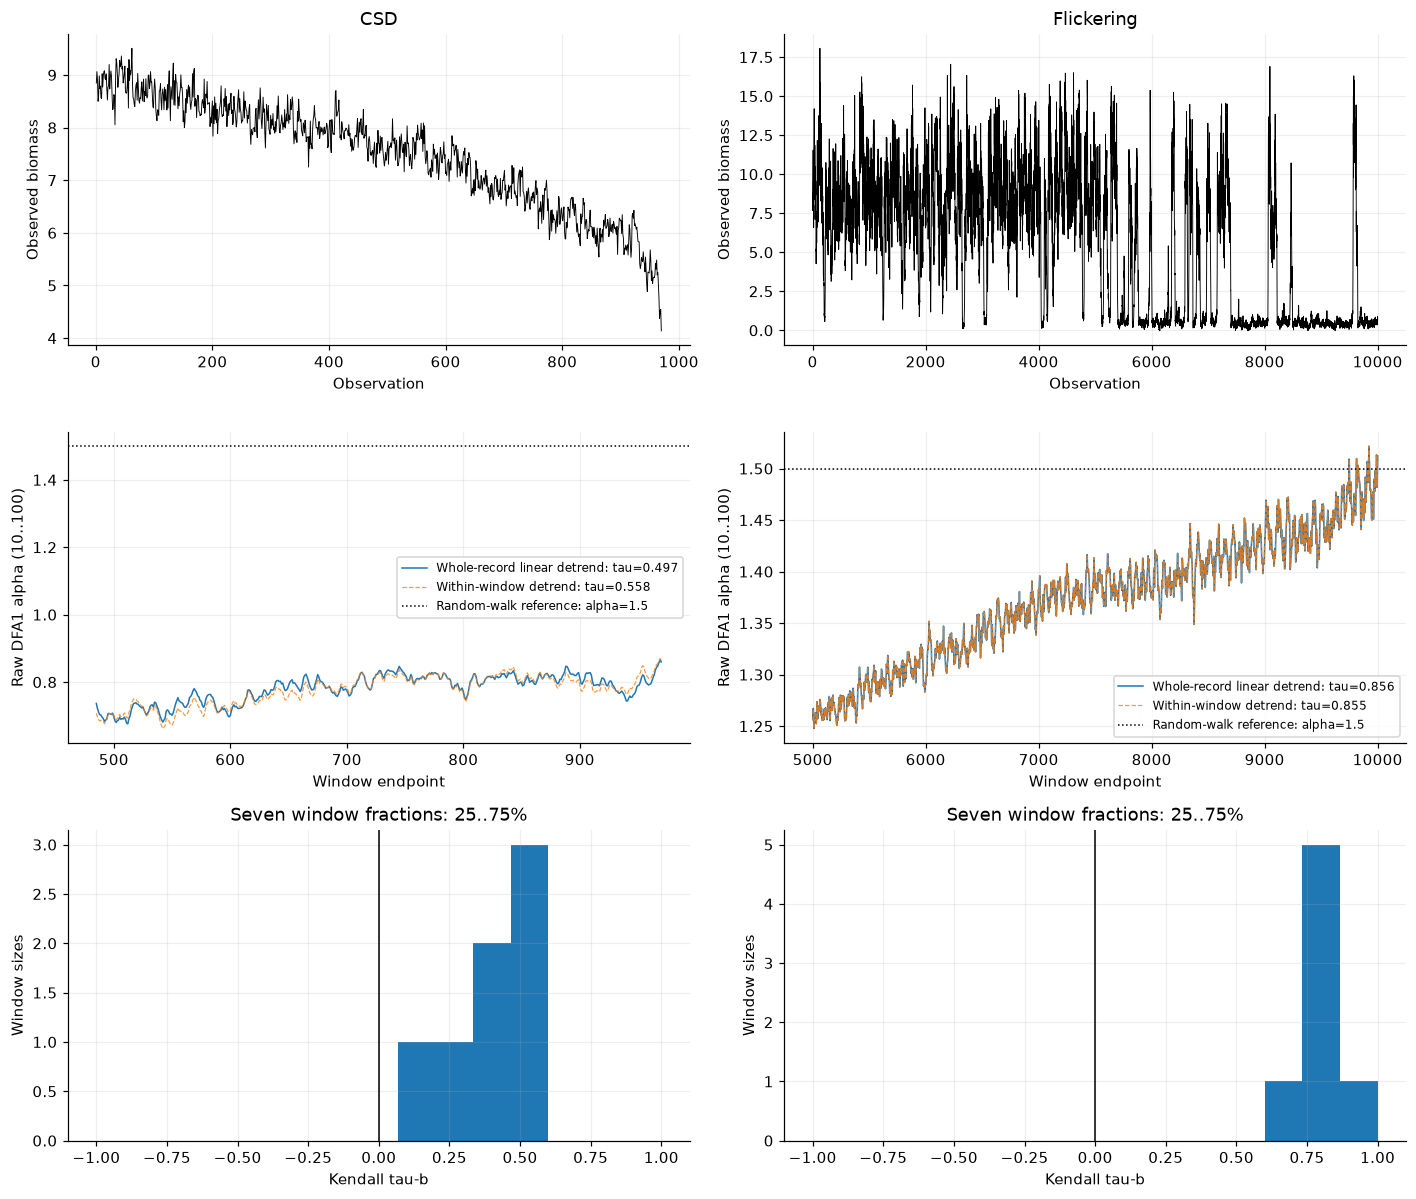

| Scenario | Window | DFA tau-b | Alpha đầu | Alpha cuối | Min alpha | Max alpha | R² đầu | R² cuối | Within-window tau | Max \|alpha whole - within\| |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| CSD | 485 | 0.496551 | 0.736454 | 0.859669 | 0.675909 | 0.865801 | 0.962295 | 0.972854 | 0.55766 | 0.0312212 |
| Flickering | 5000 | 0.855583 | 1.25732 | 1.51203 | 1.24777 | 1.52177 | 0.998325 | 0.996526 | 0.855316 | 0.000442947 |

| Scenario | Window | Fraction | Số estimates | Tau-b |
| --- | --- | --- | --- | --- |
| CSD | 242 | 0.249485 | 729 | 0.293628 |
| CSD | 340 | 0.350515 | 631 | 0.405579 |
| CSD | 436 | 0.449485 | 535 | 0.467241 |
| CSD | 485 | 0.5 | 486 | 0.496551 |
| CSD | 534 | 0.550515 | 437 | 0.514559 |
| CSD | 630 | 0.649485 | 341 | 0.368949 |
| CSD | 728 | 0.750515 | 243 | 0.183213 |
| Flickering | 2500 | 0.25 | 7501 | 0.758909 |
| Flickering | 3500 | 0.35 | 6501 | 0.844293 |
| Flickering | 4500 | 0.45 | 5501 | 0.871787 |
| Flickering | 5000 | 0.5 | 5001 | 0.855583 |
| Flickering | 5500 | 0.55 | 4501 | 0.824071 |
| Flickering | 6500 | 0.65 | 3501 | 0.748768 |
| Flickering | 7500 | 0.75 | 2501 | 0.680285 |

In [11]:
DFA_SCALES = np.unique(np.geomspace(10, 100, 20).astype(int))
DFA_FRACTIONS = np.array([0.25, 0.35, 0.45, 0.50, 0.55, 0.65, 0.75])
dfa_trajectories = {}
dfa_sensitivity_rows = []
dfa_rows = []
dfa_processed = {}


def dfa_window_fit(x: np.ndarray) -> dict:
    """Fit DFA1 on the fixed 10..100 scale grid."""
    return ews.dfa(x, DFA_SCALES, order=1, min_segments=2)


def dfa_with_linear_detrend(x: np.ndarray) -> float:
    """Remove a window's input trend before computing raw DFA alpha."""
    return dfa_window_fit(signal.detrend(x, type="linear"))["global_alpha"]


for scenario, record in records.items():
    linear_residual = signal.detrend(record["raw"], type="linear")
    dfa_processed[scenario] = linear_residual
    widths = np.unique(
        np.rint(DFA_FRACTIONS * linear_residual.size).astype(int)
    )
    for width in widths:
        values, positions = ews.rolling_metric(
            linear_residual,
            ews.dfa_exponent,
            int(width),
            scales=DFA_SCALES,
            order=1,
            min_segments=2,
        )
        dfa_trajectories[(scenario, int(width))] = (values, positions)
        dfa_sensitivity_rows.append(
            {
                "scenario": scenario,
                "width": int(width),
                "fraction": float(width / linear_residual.size),
                "tau": ews.kendall_tau(values, positions),
                "n_windows": values.size,
            }
        )
    width = record["window"]
    values, positions = dfa_trajectories[(scenario, width)]
    within, within_positions = ews.rolling_metric(
        record["raw"], dfa_with_linear_detrend, width
    )
    np.testing.assert_array_equal(positions, within_positions)
    dfa_trajectories[(scenario, "within-window")] = (within, within_positions)
    first = dfa_window_fit(linear_residual[:width])
    last = dfa_window_fit(linear_residual[-width:])
    for index in [0, values.size // 2, values.size - 1]:
        checked = dfa_window_fit(linear_residual[index : index + width])
        np.testing.assert_allclose(values[index], checked["global_alpha"])
    dfa_rows.append(
        {
            "scenario": scenario,
            "window": width,
            "tau": ews.kendall_tau(values, positions),
            "first_alpha": float(values[0]),
            "last_alpha": float(values[-1]),
            "minimum_alpha": float(values.min()),
            "maximum_alpha": float(values.max()),
            "first_r2": first["global_R2"],
            "last_r2": last["global_R2"],
            "within_tau": ews.kendall_tau(within, within_positions),
            "maximum_detrend_difference": float(
                np.max(np.abs(values - within))
            ),
        }
    )
figure, axes = plt.subplots(3, 2, figsize=(13, 11))
for column, (scenario, record) in enumerate(records.items()):
    time = np.arange(1, record["raw"].size + 1)
    axes[0, column].plot(time, record["raw"], color="black", lw=0.6)
    axes[0, column].set(
        title=scenario, ylabel="Observed biomass", xlabel="Observation"
    )
    row = next(row for row in dfa_rows if row["scenario"] == scenario)
    values, positions = dfa_trajectories[(scenario, record["window"])]
    within, _ = dfa_trajectories[(scenario, "within-window")]
    axes[1, column].plot(
        positions + 1,
        values,
        lw=1,
        label=f"Whole-record linear detrend: tau={row['tau']:.3f}",
    )
    axes[1, column].plot(
        positions + 1,
        within,
        "--",
        lw=0.8,
        alpha=0.8,
        label=f"Within-window detrend: tau={row['within_tau']:.3f}",
    )
    axes[1, column].axhline(
        1.5,
        color="black",
        ls=":",
        lw=1,
        label="Random-walk reference: alpha=1.5",
    )
    axes[1, column].set(
        ylabel="Raw DFA1 alpha (10..100)", xlabel="Window endpoint"
    )
    axes[1, column].legend(fontsize=8)
    taus = [
        row["tau"]
        for row in dfa_sensitivity_rows
        if row["scenario"] == scenario
    ]
    axes[2, column].hist(taus, bins=np.linspace(-1, 1, 16))
    axes[2, column].axvline(0, color="black", lw=1)
    axes[2, column].set(
        xlabel="Kendall tau-b",
        ylabel="Window sizes",
        title="Seven window fractions: 25..75%",
    )
figure.tight_layout()
plt.show()
plt.close(figure)
show_table(
    dfa_rows,
    {
        "scenario": "Scenario",
        "window": "Window",
        "tau": "DFA tau-b",
        "first_alpha": "Alpha đầu",
        "last_alpha": "Alpha cuối",
        "minimum_alpha": "Min alpha",
        "maximum_alpha": "Max alpha",
        "first_r2": "R² đầu",
        "last_r2": "R² cuối",
        "within_tau": "Within-window tau",
        "maximum_detrend_difference": "Max |alpha whole - within|",
    },
)
show_table(
    dfa_sensitivity_rows,
    {
        "scenario": "Scenario",
        "width": "Window",
        "fraction": "Fraction",
        "n_windows": "Số estimates",
        "tau": "Tau-b",
    },
)

### 7.1. Quan sát F(s) trước khi diễn giải alpha

Alpha là slope fit, nên phải nhìn cả F(s) và goodness of fit. Hai plots dưới
hiển thị window đầu/cuối 50% của mỗi scenario, cùng đường OLS log-log.
R² cao chỉ cho biết fit tốt trên dải 10–100; không chứng minh một scaling
law ở mọi scale. Các đoạn box của profile là dữ liệu để tính RMS, còn các
rolling windows dùng để theo dõi sự thay đổi theo thời gian.

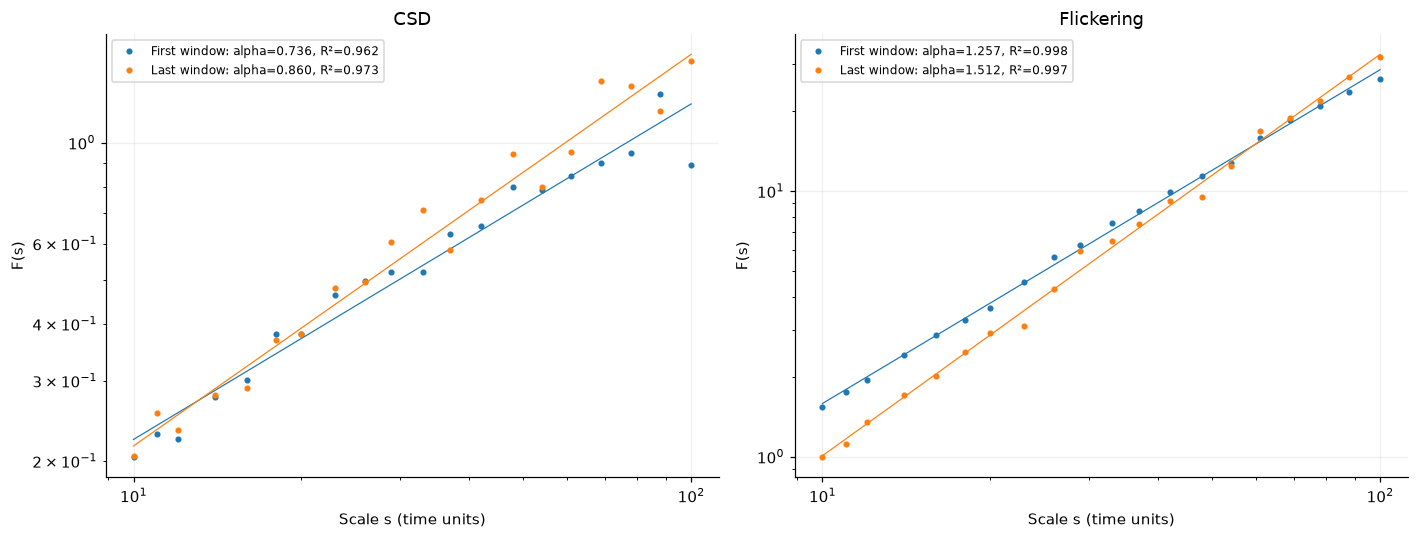

**CSD:** tau ở window 50% = 0.4966; alpha 0.736 → 0.860. Sensitivity có 7/7 widths cho tau dương, range [0.1832, 0.5146]. Đọc các giá trị này cùng trajectories và F(s), không chỉ dựa vào endpoint.

**Flickering:** tau ở window 50% = 0.8556; alpha 1.257 → 1.512. Sensitivity có 7/7 widths cho tau dương, range [0.6803, 0.8718]. Đọc các giá trị này cùng trajectories và F(s), không chỉ dựa vào endpoint.

In [12]:
figure, axes = plt.subplots(1, 2, figsize=(13, 5))
for column, (scenario, record) in enumerate(records.items()):
    processed = dfa_processed[scenario]
    width = record["window"]
    for label, source, color in [
        ("First window", processed[:width], "tab:blue"),
        ("Last window", processed[-width:], "tab:orange"),
    ]:
        result = dfa_window_fit(source)
        alpha = result["global_alpha"]
        axes[column].loglog(
            result["scales"],
            result["fluctuations"],
            "o",
            ms=3,
            color=color,
            label=f"{label}: alpha={alpha:.3f}, R²={result['global_R2']:.3f}",
        )
        axes[column].loglog(
            result["scales"],
            10 ** result["global_intercept"] * result["scales"] ** alpha,
            lw=0.8,
            color=color,
        )
    axes[column].set(
        title=scenario, xlabel="Scale s (time units)", ylabel="F(s)"
    )
    axes[column].legend(fontsize=8)
figure.tight_layout()
plt.show()
plt.close(figure)
dfa_sensitivity_summary = {}
for scenario in records:
    taus = np.array(
        [
            row["tau"]
            for row in dfa_sensitivity_rows
            if row["scenario"] == scenario
        ]
    )
    dfa_sensitivity_summary[scenario] = {
        "minimum_tau": float(taus.min()),
        "maximum_tau": float(taus.max()),
        "positive_windows": int(np.count_nonzero(taus > 0)),
        "n_widths": taus.size,
    }
    primary = next(row for row in dfa_rows if row["scenario"] == scenario)
    display(
        Markdown(
            f"**{scenario}:** tau ở window 50% = {primary['tau']:.4f}; "
            f"alpha {primary['first_alpha']:.3f} → "
            f"{primary['last_alpha']:.3f}. Sensitivity có "
            f"{np.count_nonzero(taus > 0)}/{taus.size} widths cho tau dương, "
            f"range [{taus.min():.4f}, {taus.max():.4f}]. "
            "Đọc các giá trị này cùng trajectories và F(s), "
            "không chỉ dựa vào endpoint."
        )
    )

**Điều rút ra từ realization đã cố định:** CSD có tau 0.496551,
alpha đầu/cuối 0.736454 → 0.859669; memory tăng nhưng chưa gần mốc 1.5.
Sensitivity CSD dương 7/7 widths, range 0.183213–0.514559: khớp hướng,
chưa khớp mô tả strong trends trên toàn grid của paper. Flickering có tau
0.855583, alpha 1.25732 → 1.51203 và sensitivity dương 7/7 widths,
range 0.680285–0.871787: tín hiệu rõ hơn và dao động quanh 1.5 ở cuối.
Các transitions giữa regimes cũng ảnh hưởng slope; không suy ra cơ chế
critical slowing down chỉ từ alpha của flickering.

Detrend riêng từng window cho tau CSD 0.557660, flickering 0.855316;
max chênh lệch alpha lần lượt 0.0312212 và 0.000442947. Trong trường hợp
này lựa chọn detrend không đổi dấu trend, nhưng có tác động lên CSD.
Detrending toàn record có thông tin tương lai, nên đây là phân tích offline.
Không đổi seed, không lọc bớt cấu hình bất lợi và không gắn nhãn một regime
chỉ từ alpha.

Figure 3 được tái tạo về workflow, raw-exponent trajectories và sensitivity;
chưa tái tạo calibrated indicator, exact curves hay exact tau của tác giả.
Overlapping windows phụ thuộc mạnh, nên tau là trend mô tả, không kèm
independent-sample p-value. Figure 11 của paper kiểm tra ACF/SD/skewness;
không tự gán surrogate significance đó cho DFA. Tiếp theo khảo sát các
metrics mở rộng và robustness của các indicators Figure 2.

## 8. Indicators mở rộng: nhiều thước đo có thêm bằng chứng không?

OLS AR(1) dùng `demean=True, intercept=False` để gần convention R. Hai
return-rate definitions đều suy ra từ cùng phi; chúng không phải hai bằng
chứng độc lập. Khi phi dương tăng về 1, `1/phi` giảm về 1 còn `1-phi` giảm
về 0. Giữ hai định nghĩa riêng thay vì gán cùng một interpretation vật lý.

CV tính trên **raw biomass**, vì mean residual/standardized gần 0 khiến CV
không ổn định. Kurtosis dùng Pearson, Gaussian reference là 3. Welch Hann
với nperseg=256 giảm độ biến động của spectral estimate; ratio là point
PSD tại 0.05/0.5 cycles per observation. Beta fit trong 0.02–0.4 và là âm
log-log slope. Những lựa chọn này cố định, khác `spec.ar` của R.

**Cách đọc:** đặt OLS cạnh hai return rates, rồi nhìn moments và spectral
indicators. Một beta hoặc ratio không monotonic không phủ nhận rising
ACF; chúng đo những phần khác nhau của correlation structure và chịu ảnh
hưởng bởi dải tần đã chọn. Đây là extended verification, chưa là matching
của một supplementary figure cụ thể trong paper.

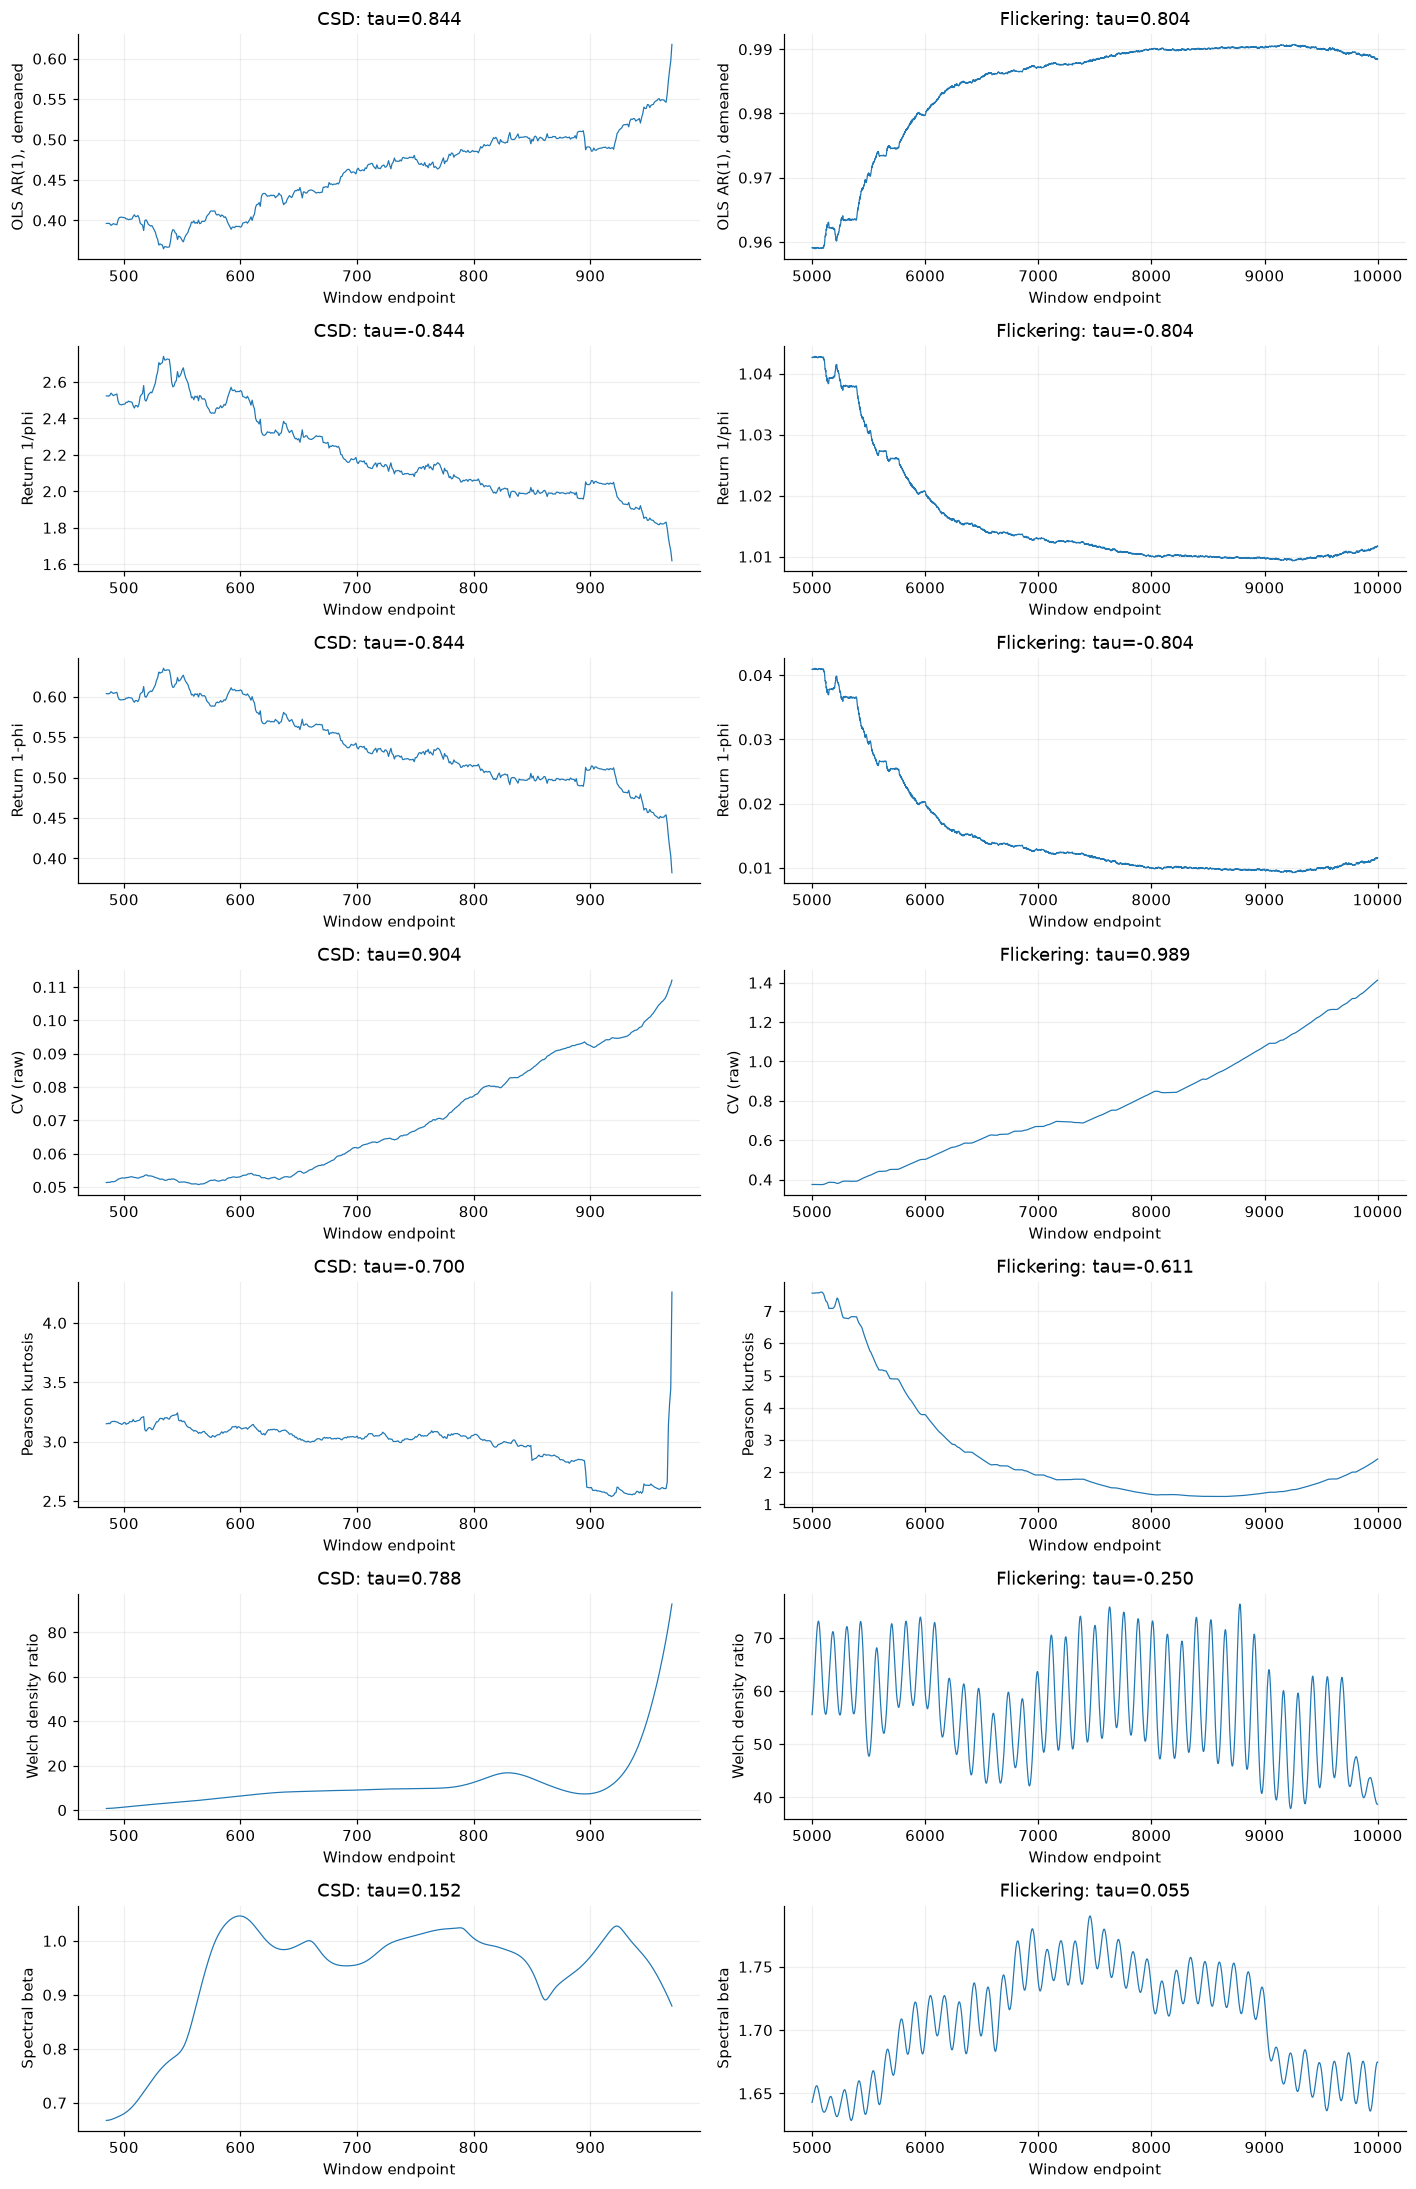

| Scenario | Indicator | Tau-b | Giá trị đầu | Giá trị cuối |
| --- | --- | --- | --- | --- |
| CSD | OLS AR(1), demeaned | 0.844114 | 0.396253 | 0.617646 |
| CSD | Return 1/phi | -0.844114 | 2.52364 | 1.61905 |
| CSD | Return 1-phi | -0.844114 | 0.603747 | 0.382354 |
| CSD | CV (raw) | 0.903746 | 0.0513418 | 0.112049 |
| CSD | Pearson kurtosis | -0.700276 | 3.15103 | 4.25927 |
| CSD | Welch density ratio | 0.788146 | 0.728201 | 92.7981 |
| CSD | Spectral beta | 0.152229 | 0.667456 | 0.879302 |
| Flickering | OLS AR(1), demeaned | 0.804356 | 0.959096 | 0.988436 |
| Flickering | Return 1/phi | -0.804356 | 1.04265 | 1.0117 |
| Flickering | Return 1-phi | -0.804356 | 0.0409044 | 0.0115636 |
| Flickering | CV (raw) | 0.988513 | 0.375246 | 1.4127 |
| Flickering | Pearson kurtosis | -0.610638 | 7.56155 | 2.40804 |
| Flickering | Welch density ratio | -0.249944 | 55.5246 | 38.7166 |
| Flickering | Spectral beta | 0.0546203 | 1.6429 | 1.67473 |

In [13]:
EXTENDED_METRICS = {
    "OLS AR(1), demeaned": partial(
        ews.ar1_coefficient, intercept=False, demean=True
    ),
    "Return 1/phi": partial(ews.return_rate, intercept=False, demean=True),
    "Return 1-phi": partial(
        ews.return_rate, definition="decay", intercept=False, demean=True
    ),
    "CV (raw)": ews.coefficient_of_variation,
    "Pearson kurtosis": ews.kurtosis,
    "Welch density ratio": partial(
        ews.spectral_ratio, method="welch", window="hann", nperseg=256
    ),
    "Spectral beta": partial(
        ews.spectral_exponent,
        method="welch",
        window="hann",
        nperseg=256,
        frequency_range=(0.02, 0.4),
    ),
}
extended_rows = []
figure, axes = plt.subplots(7, 2, figsize=(13, 20))
for column, (scenario, record) in enumerate(records.items()):
    for row, (metric_name, metric) in enumerate(EXTENDED_METRICS.items()):
        source = (
            record["raw"] if metric_name == "CV (raw)" else record["processed"]
        )
        values, positions = ews.rolling_metric(
            source, metric, record["window"]
        )
        tau = ews.kendall_tau(values, positions)
        extended_rows.append(
            {
                "scenario": scenario,
                "metric": metric_name,
                "tau": tau,
                "first_value": float(values[0]),
                "last_value": float(values[-1]),
            }
        )
        axes[row, column].plot(positions + 1, values, lw=0.8)
        axes[row, column].set(
            title=f"{scenario}: tau={tau:.3f}",
            ylabel=metric_name,
            xlabel="Window endpoint",
        )
figure.tight_layout()
plt.show()
plt.close(figure)

show_table(
    extended_rows,
    {
        "scenario": "Scenario",
        "metric": "Indicator",
        "tau": "Tau-b",
        "first_value": "Giá trị đầu",
        "last_value": "Giá trị cuối",
    },
)

### Nhìn trực tiếp phổ đầu và cuối record

So sánh Welch PSD ở window đầu và cuối với cùng segment length và sampling
frequency. Spectral reddening liên quan đến phần power ở tần số thấp, nhưng
figure không tự suy ra statistical significance. Trục log-log bỏ DC để
tránh log(0); normalization density giữ units x² per frequency unit.

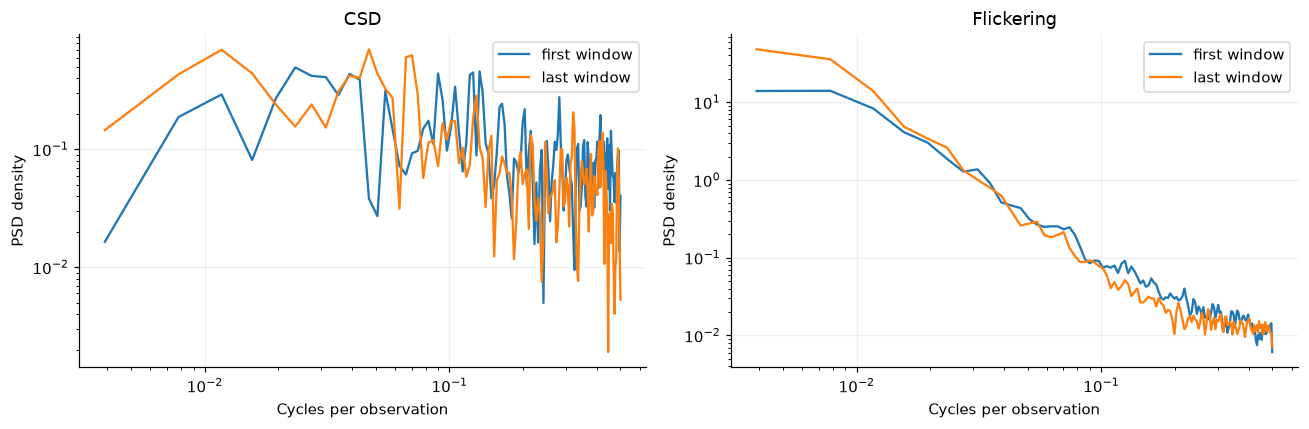

In [14]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, (scenario, record) in zip(axes, records.items()):
    nperseg = min(256, record["window"])
    spectra = []
    for label, source in [
        ("first window", record["processed"][: record["window"]]),
        ("last window", record["processed"][-record["window"] :]),
    ]:
        frequency, density = ews.power_spectral_density(
            source, method="welch", window="hann", nperseg=nperseg
        )
        axis.loglog(frequency[1:], density[1:], label=label)
        spectra.append(density)
    axis.set(
        title=scenario, xlabel="Cycles per observation", ylabel="PSD density"
    )
    axis.legend()
figure.tight_layout()
plt.show()
plt.close(figure)

**Điều rút ra:** OLS và return rates kể cùng câu chuyện memory qua các biến
đổi khác nhau. Kurtosis và spectral indicators không nhất thiết có trend
mạnh hoặc cùng hướng ở hai kịch bản. Số lượng indicators tăng không tự làm
kết luận chắc hơn. Ta quay lại ba indicators chính và thử thay đổi lựa chọn
phân tích để xem phần nào của câu chuyện đứng vững.

## 9. Thay window và filtering: Figure 10

Giữ **cùng CSD realization**, tính lại ACF, SD và skewness ở window 243,
253,...,723, thêm 485 và 728; bandwidth 5,25,...,185, thêm 97 và 200.
51 window sizes × 12 bandwidths = 612 cấu hình. Các biên 25%/75% đã được
làm tròn theo observations. Bandwidth dùng đơn vị R `ksmooth`, không dùng
sigma trực tiếp. Không chọn cấu hình bằng tau lớn nhất.

Để tính nhanh, vectorize đúng công thức core trên overlapping windows và
kiểm tra raw/residual trajectories với `rolling_metric` trước khi dùng.
Đây là thay cách tính, không thay estimator.

**Cách đọc:** heatmap đỏ nghĩa tau dương, xanh nghĩa tau âm, trắng gần 0;
histogram bên phải cho phân bố tau qua lưới. Triangle là cấu hình chính
(window=485, bandwidth=97). Robustness đòi hỏi vừa đúng hướng vừa đủ mạnh;
99% cấu hình cùng dấu nhưng tau gần 0 chưa là một tín hiệu mạnh.

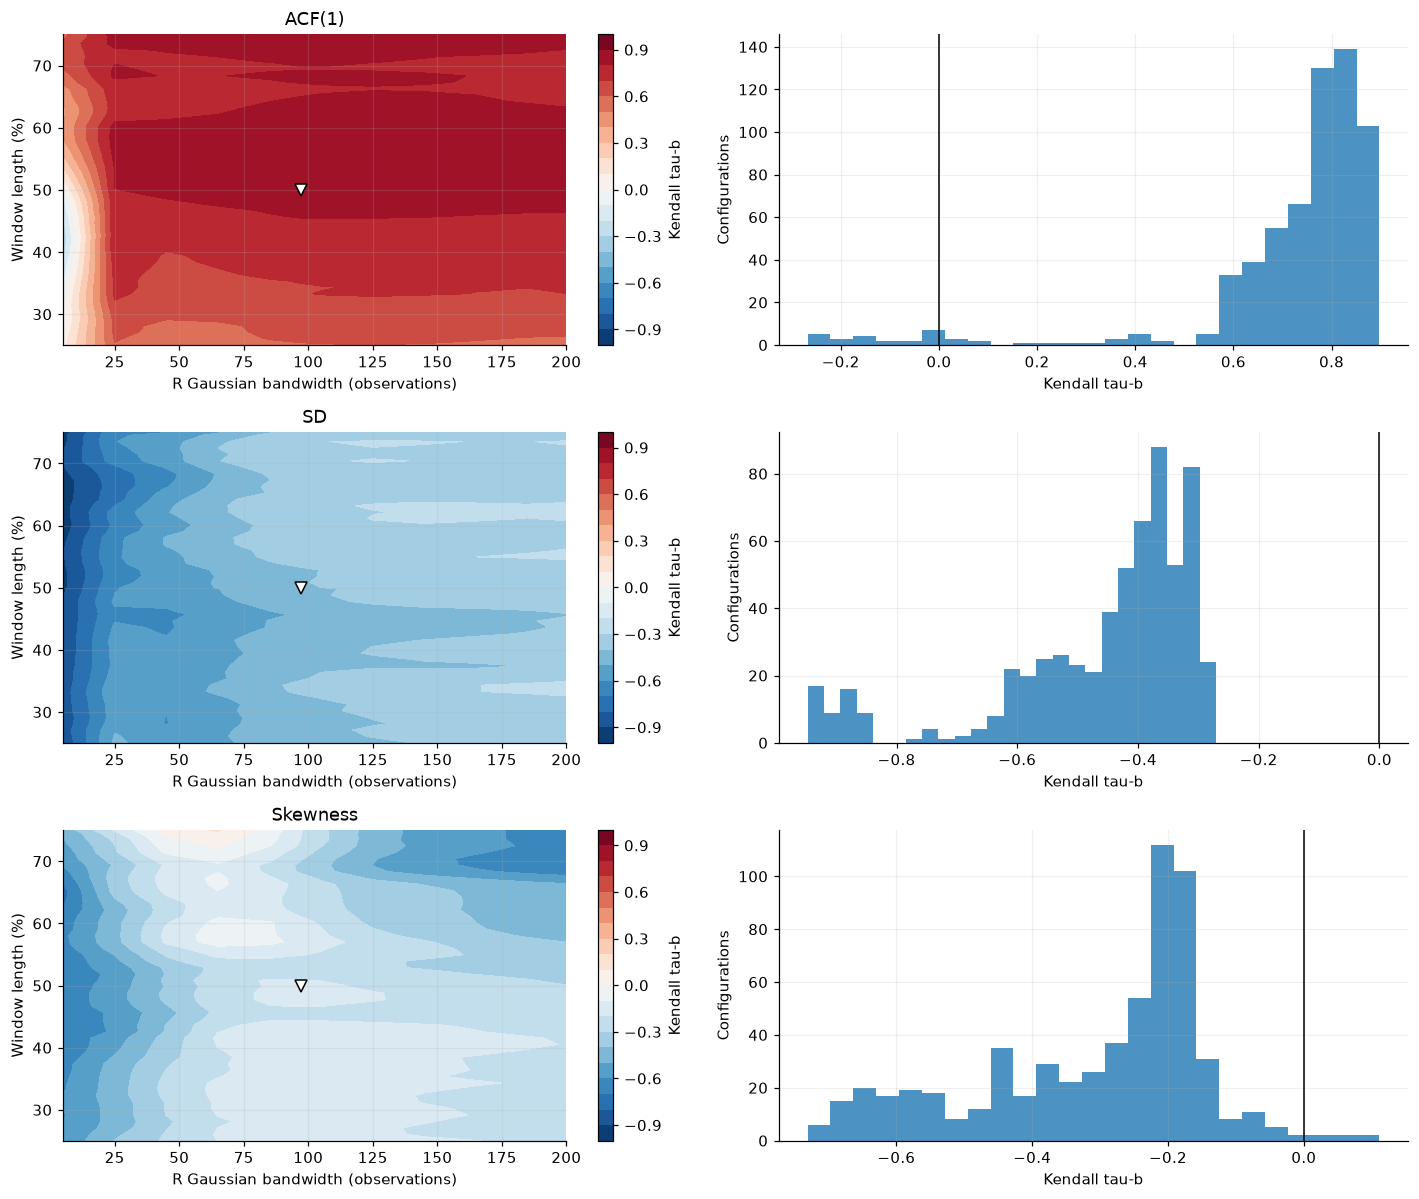

| Indicator | Min tau | Max tau | Tỉ lệ hướng kỳ vọng | Tỉ lệ \|tau\| >0.5 |
| --- | --- | --- | --- | --- |
| ACF(1) | -0.267643 | 0.897413 | 0.964052 | 0.931373 |
| SD | -0.947441 | -0.270995 | 0 | 0.284314 |
| Skewness | -0.73076 | 0.111247 | 0.990196 | 0.165033 |

| Indicator | Bandwidth region | Min tau | Max tau | Tỉ lệ hướng kỳ vọng |
| --- | --- | --- | --- | --- |
| ACF(1) | narrow bandwidth <=25 | -0.267643 | 0.84437 | 0.784314 |
| ACF(1) | middle bandwidth 45..105 | 0.535446 | 0.894256 | 1 |
| ACF(1) | wide bandwidth >=125 | 0.584451 | 0.897413 | 1 |
| SD | narrow bandwidth <=25 | -0.947441 | -0.48165 | 0 |
| SD | middle bandwidth 45..105 | -0.627903 | -0.301179 | 0 |
| SD | wide bandwidth >=125 | -0.455681 | -0.270995 | 0 |
| Skewness | narrow bandwidth <=25 | -0.73076 | -0.184029 | 1 |
| Skewness | middle bandwidth 45..105 | -0.433155 | 0.111247 | 0.976471 |
| Skewness | wide bandwidth >=125 | -0.700856 | -0.156432 | 1 |

In [15]:
def primary_window_values(x: np.ndarray, width: int) -> dict:
    """Vectorize the three core formulas over complete overlapping windows."""
    windows = np.lib.stride_tricks.sliding_window_view(x, width)
    centered = windows - windows.mean(axis=1, keepdims=True)
    energy = np.einsum("ij,ij->i", centered, centered)
    covariance = np.einsum("ij,ij->i", centered[:, :-1], centered[:, 1:])
    return {
        "ACF(1)": covariance / energy,
        "SD": np.sqrt(energy / (width - 1)),
        "Skewness": stats.skew(windows, axis=1, bias=True),
    }


for source in [raw_csd, residual_csd]:
    fast_values = primary_window_values(source, 485)
    for metric_name, metric in PRIMARY_METRICS.items():
        slow_values, _ = ews.rolling_metric(source, metric, 485)
        np.testing.assert_allclose(
            fast_values[metric_name], slow_values, rtol=1e-11, atol=1e-12
        )
window_sizes = np.unique(np.r_[np.arange(243, 728, 10), 485, 728])
bandwidths = np.unique(np.r_[np.arange(5, 201, 20), 97, 200])
sensitivity = {
    name: np.empty((window_sizes.size, bandwidths.size))
    for name in PRIMARY_METRICS
}
sensitivity_rows = []
for column, bandwidth in enumerate(bandwidths):
    residual, _ = ews.gaussian_detrend(raw_csd, float(bandwidth))
    for row, width in enumerate(window_sizes):
        estimates = primary_window_values(residual, int(width))
        for metric_name, values in estimates.items():
            tau = ews.kendall_tau(values)
            sensitivity[metric_name][row, column] = tau
            sensitivity_rows.append(
                {
                    "window": int(width),
                    "window_percent": 100 * width / 970,
                    "bandwidth": int(bandwidth),
                    "metric": metric_name,
                    "tau": tau,
                }
            )
figure, axes = plt.subplots(3, 2, figsize=(13, 11))
sensitivity_summary = {}
for row, (metric_name, grid) in enumerate(sensitivity.items()):
    expected_direction = -1 if metric_name == "Skewness" else 1
    sensitivity_summary[metric_name] = {
        "minimum_tau": float(grid.min()),
        "maximum_tau": float(grid.max()),
        "fraction_expected_sign": float(
            np.mean(grid * expected_direction > 0)
        ),
        "fraction_abs_tau_above_0.5": float(np.mean(np.abs(grid) > 0.5)),
    }
    contour = axes[row, 0].contourf(
        bandwidths,
        100 * window_sizes / 970,
        grid,
        levels=np.linspace(-1, 1, 21),
        cmap="RdBu_r",
        extend="neither",
    )
    axes[row, 0].plot(97, 50, "kv", mfc="white", ms=8)
    axes[row, 0].set(
        title=metric_name,
        xlabel="R Gaussian bandwidth (observations)",
        ylabel="Window length (%)",
    )
    figure.colorbar(contour, ax=axes[row, 0], label="Kendall tau-b")
    axes[row, 1].hist(grid.ravel(), bins=25, color="tab:blue", alpha=0.8)
    axes[row, 1].axvline(0, color="black", lw=1)
    axes[row, 1].set(xlabel="Kendall tau-b", ylabel="Configurations")
figure.tight_layout()
plt.show()
plt.close(figure)

regions = []
for metric_name, grid in sensitivity.items():
    for label, mask in [
        ("narrow bandwidth <=25", bandwidths <= 25),
        ("middle bandwidth 45..105", (bandwidths >= 45) & (bandwidths <= 105)),
        ("wide bandwidth >=125", bandwidths >= 125),
    ]:
        subset = grid[:, mask]
        expected_direction = -1 if metric_name == "Skewness" else 1
        regions.append(
            {
                "metric": metric_name,
                "region": label,
                "minimum_tau": float(subset.min()),
                "maximum_tau": float(subset.max()),
                "fraction_expected_sign": float(
                    np.mean(subset * expected_direction > 0)
                ),
            }
        )

show_table(
    [
        {"metric": name, **values}
        for name, values in sensitivity_summary.items()
    ],
    {
        "metric": "Indicator",
        "minimum_tau": "Min tau",
        "maximum_tau": "Max tau",
        "fraction_expected_sign": "Tỉ lệ hướng kỳ vọng",
        "fraction_abs_tau_above_0.5": "Tỉ lệ |tau| >0.5",
    },
)
show_table(
    regions,
    {
        "metric": "Indicator",
        "region": "Bandwidth region",
        "minimum_tau": "Min tau",
        "maximum_tau": "Max tau",
        "fraction_expected_sign": "Tỉ lệ hướng kỳ vọng",
    },
)

**Điều rút ra:** ACF tăng ổn định hơn với bandwidth >=45, nhưng bandwidth
rất nhỏ có thể đổi hướng. Skewness thường có dấu âm, còn strength yếu ở
nhiều cấu hình. SD residual âm trên toàn lưới của primary realization,
khác pattern paper “thường tăng trừ bandwidth nhỏ”. Vì vậy sensitivity
không được dùng để che discrepancy, và robustness chưa đồng nghĩa với
significance. Tiếp theo ta hỏi liệu stationary correlation có thể tạo
trend mạnh như vậy chỉ bởi ngẫu nhiên không.

## 10. So với stationary null: Figure 11 tại cấu hình chính

Windows chồng lấn nên không dùng independent-sample p-value của Kendall.
Null model ở đây là **stationary Gaussian ARMA** fit trên CSD residual.
Fit p=1..4, q=0..4, zero mean; chọn AIC nhỏ nhất trong các candidates hội tụ,
stationary và invertible, theo miền tìm kiếm đọc từ R `surrogates_ews`.
Optimizer/constraints có thể khác R; AIC, warnings và roots đều được đọc
trước khi diễn giải null. Fit stationary ARMA không chứng minh toàn bộ
residual thực sự stationary hoặc có Gaussian marginal distribution.

Sinh 1.000 surrogates, seed=2014, burn-in=5.000, length=970, window=485.
Không detrend lần nữa vì model được fit trên processed residual. Tail
được chọn từ kỳ vọng trước kết quả: upper cho rising ACF/SD, lower cho
signed skewness của downward transition. Monte Carlo p:

$$ p=\frac{1+\#\{\text{surrogate tau extreme theo hướng kỳ vọng}\}}{1001}. $$

Giới hạn: chỉ kiểm tra cấu hình chính. Full significance heatmap cho toàn
bandwidth/window grid còn **deferred**; không khẳng định đã tái tạo Figure 11
trên toàn parameter space.

In [16]:
arma_candidates = []
fitted_models = []
for p in range(1, 5):
    for q in range(5):
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            try:
                fitted = ARIMA(
                    residual_csd,
                    order=(p, 0, q),
                    trend="n",
                    enforce_stationarity=True,
                    enforce_invertibility=True,
                ).fit(method_kwargs={"maxiter": 300})
                converged = bool(fitted.mle_retvals.get("converged", False))
                valid_roots = np.all(np.abs(fitted.arroots) > 1) and np.all(
                    np.abs(fitted.maroots) > 1
                )
                eligible = (
                    converged and valid_roots and np.isfinite(fitted.aic)
                )
                if eligible:
                    fitted_models.append(fitted)
                error = ""
                aic = float(fitted.aic)
            except (ValueError, np.linalg.LinAlgError) as exc:
                eligible = converged = False
                aic = None
                error = str(exc)
        arma_candidates.append(
            {
                "p": p,
                "q": q,
                "aic": aic,
                "converged": converged,
                "eligible": eligible,
                "error": error,
                "warnings": " | ".join((str(item.message) for item in caught)),
            }
        )
if not fitted_models:
    raise RuntimeError("No converged stationary ARMA candidate")
best_arma = min(fitted_models, key=lambda model: model.aic)
process = ArmaProcess(
    np.r_[1, -best_arma.arparams], np.r_[1, best_arma.maparams]
)
assert process.isstationary and process.isinvertible
innovation_variance = dict(zip(best_arma.param_names, best_arma.params))[
    "sigma2"
]
arma_summary = {
    "order": list(best_arma.model.order),
    "aic": float(best_arma.aic),
    "parameters": dict(
        zip(
            best_arma.param_names, [float(value) for value in best_arma.params]
        )
    ),
    "minimum_ar_root_modulus": float(np.min(np.abs(best_arma.arroots))),
    "minimum_ma_root_modulus": float(np.min(np.abs(best_arma.maroots)))
    if best_arma.maroots.size
    else None,
    "candidate_count": len(arma_candidates),
    "eligible_count": len(fitted_models),
    "seed": 2014,
    "burnin": 5000,
    "refilter_surrogates": False,
}

show_table(
    arma_candidates,
    {
        "p": "p",
        "q": "q",
        "aic": "AIC",
        "converged": "Hội tụ",
        "eligible": "Eligible",
        "warnings": "Fit warnings",
        "error": "Error",
    },
)
show_table(
    [
        {"parameter": name, "value": value}
        for name, value in arma_summary["parameters"].items()
    ],
    {"parameter": "Selected model parameter", "value": "Giá trị"},
)
display(
    Markdown(
        f"Selected ARMA order: **{arma_summary['order']}**, "
        f"AIC=**{arma_summary['aic']:.3f}**; "
        f"eligible {arma_summary['eligible_count']}/"
        f"{arma_summary['candidate_count']}. "
        f"Min AR root modulus={arma_summary['minimum_ar_root_modulus']:.9f}; "
        f"min MA root modulus={arma_summary['minimum_ma_root_modulus']}."
    )
)

| p | q | AIC | Hội tụ | Eligible | Fit warnings | Error |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | 0 | -195.663 | True | True |  |  |
| 1 | 1 | -214.815 | True | True |  |  |
| 1 | 2 | -212.839 | True | True |  |  |
| 1 | 3 | -211.125 | True | True |  |  |
| 1 | 4 | -210.138 | True | True |  |  |
| 2 | 0 | -213.897 | True | True |  |  |
| 2 | 1 | -212.844 | True | True |  |  |
| 2 | 2 | -210.983 | True | True |  |  |
| 2 | 3 | -209.338 | True | True |  |  |
| 2 | 4 | -207.317 | True | True |  |  |
| 3 | 0 | -212.479 | True | True |  |  |
| 3 | 1 | -210.975 | True | True |  |  |
| 3 | 2 | -209.193 | True | True |  |  |
| 3 | 3 | -216.313 | True | True |  |  |
| 3 | 4 | -211.506 | True | True |  |  |
| 4 | 0 | -211.619 | True | True |  |  |
| 4 | 1 | -209.628 | True | True |  |  |
| 4 | 2 | -214.063 | True | True | Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.  /  Non-invertible starting MA parameters found. Using zeros as starting parameters. |  |
| 4 | 3 | -211.466 | True | True |  |  |
| 4 | 4 | -222.238 | True | True |  |  |

| Selected model parameter | Giá trị |
| --- | --- |
| ar.L1 | 0.0975453 |
| ar.L2 | 1.11333 |
| ar.L3 | 0.488529 |
| ar.L4 | -0.733353 |
| ma.L1 | 0.329061 |
| ma.L2 | -0.845846 |
| ma.L3 | -0.796446 |
| ma.L4 | 0.315298 |
| sigma2 | 0.0453942 |

Selected ARMA order: **[4, 0, 4]**, AIC=**-222.238**; eligible 20/20. Min AR root modulus=1.007835291; min MA root modulus=1.0000000454741467.

**Đọc fit trước khi đọc p:** model được chọn có MA root rất gần invertibility
boundary. Điều đó không làm mất stationarity của AR polynomial đã kiểm tra,
nhưng nhắc rằng kết quả conditional theo null fit và optimizer. Burn-in
phục vụ transient của stationary simulation; không giải quyết model
misspecification. Ta giữ fit theo AIC và ghi giới hạn này, rồi tạo surrogates.

Histogram sau cho null tau distribution. Đỏ là observed tau, nét đứt là
10% null-tail threshold theo direction của từng metric. So sánh cả vị trí
observed và Monte Carlo SE, không chỉ một nhãn “significant”.

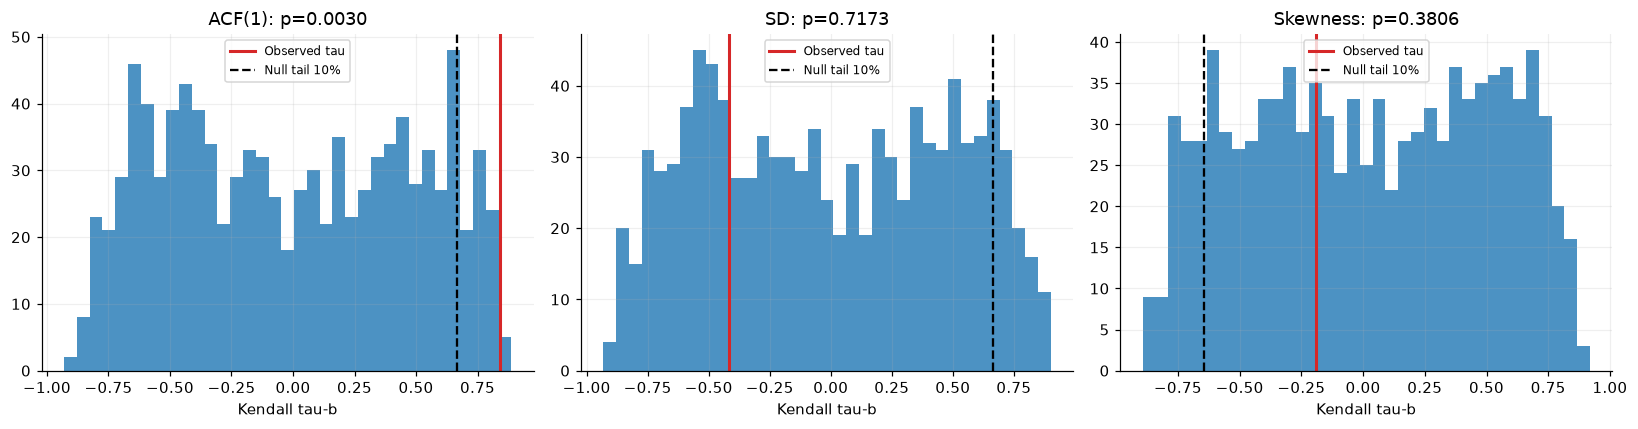

| Indicator | Observed tau | Tail | Monte Carlo p | Monte Carlo SE | Số surrogates |
| --- | --- | --- | --- | --- | --- |
| ACF(1) | 0.842892 | upper | 0.002997 | 0.00172859 | 1000 |
| SD | -0.415366 | upper | 0.717283 | 0.0142404 | 1000 |
| Skewness | -0.190785 | lower | 0.380619 | 0.0153541 | 1000 |

In [17]:
observed_trends = {
    name: ews.kendall_tau(values)
    for name, values in primary_window_values(residual_csd, 485).items()
}
surrogate_rng = np.random.default_rng(2014)
surrogate_taus = {name: np.empty(1000) for name in PRIMARY_METRICS}
for index in range(1000):
    surrogate = process.generate_sample(
        nsample=970,
        scale=np.sqrt(innovation_variance),
        distrvs=surrogate_rng.standard_normal,
        burnin=5000,
    )
    estimates = primary_window_values(surrogate, 485)
    for name, values in estimates.items():
        surrogate_taus[name][index] = ews.kendall_tau(values)
significance_rows = []
figure, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, (name, taus) in zip(axes, surrogate_taus.items()):
    observed = observed_trends[name]
    direction = "lower" if name == "Skewness" else "upper"
    extreme = taus <= observed if direction == "lower" else taus >= observed
    p_value = (1 + np.count_nonzero(extreme)) / (taus.size + 1)
    significance_rows.append(
        {
            "metric": name,
            "observed_tau": observed,
            "tail": direction,
            "p_value": p_value,
            "monte_carlo_se": float(
                np.sqrt(p_value * (1 - p_value) / taus.size)
            ),
            "surrogates": int(taus.size),
        }
    )
    axis.hist(taus, bins=35, color="tab:blue", alpha=0.8)
    axis.axvline(observed, color="tab:red", lw=2, label="Observed tau")
    quantile = np.quantile(taus, 0.1 if direction == "lower" else 0.9)
    axis.axvline(quantile, color="black", ls="--", label="Null tail 10%")
    axis.set(title=f"{name}: p={p_value:.4f}", xlabel="Kendall tau-b")
    axis.legend(fontsize=8)
figure.tight_layout()
plt.show()
plt.close(figure)

show_table(
    significance_rows,
    {
        "metric": "Indicator",
        "observed_tau": "Observed tau",
        "tail": "Tail",
        "p_value": "Monte Carlo p",
        "monte_carlo_se": "Monte Carlo SE",
        "surrogates": "Số surrogates",
    },
)

**Điều rút ra:** ACF của realization chính mạnh hơn phần lớn stationary
surrogates theo upper-tail test, còn SD và skewness không có cùng bằng
chứng. Một p nhỏ ở cấu hình này không chứng minh EWS detector có false-alarm
rate thấp, hoặc mọi cấu hình filtering đều significant. Vẫn còn một yếu tố
khác: kết luận thay đổi thế nào nếu ta lấy một realization mới cùng mô hình?

## 11. Đổi realization, giữ phương pháp: ensemble CSD

Sensitivity ở trên đổi cách phân tích cùng một record. Ensemble ở đây đổi
stochastic record nhưng giữ cutoff=970, bandwidth=97 và window=485: đó là
hai loại uncertainty khác nhau. Chạy 20 seeds 2100–2119 được đặt cố định,
không dùng ensemble để thay primary seed. Bảng từng seed giúp thấy transition
có vào vùng phân tích không; threshold <2 vẫn chỉ là diagnostic.

In [18]:
ensemble_rows = []
for seed in range(2100, 2120):
    data = simulate_resource(1000, 0.03, seed)
    residual, _ = ews.gaussian_detrend(data["observed"][:970], 97)
    values = primary_window_values(residual, 485)
    first_low = np.flatnonzero(data["biomass"] < 2)
    ensemble_rows.append(
        {
            "seed": seed,
            "first_biomass_below_2": int(first_low[0] + 1)
            if first_low.size
            else None,
            **{
                name: ews.kendall_tau(metric_values)
                for name, metric_values in values.items()
            },
        }
    )
ensemble_summary = {}
for name in PRIMARY_METRICS:
    taus = np.array([row[name] for row in ensemble_rows])
    expected_direction = -1 if name == "Skewness" else 1
    ensemble_summary[name] = {
        "minimum_tau": float(taus.min()),
        "median_tau": float(np.median(taus)),
        "maximum_tau": float(taus.max()),
        "fraction_expected_sign": float(
            np.mean(taus * expected_direction > 0)
        ),
    }

show_table(
    ensemble_rows,
    {
        "seed": "Seed",
        "first_biomass_below_2": "Lần đầu biomass <2",
        "ACF(1)": "ACF tau",
        "SD": "SD tau",
        "Skewness": "Skewness tau",
    },
)
show_table(
    [{"metric": name, **values} for name, values in ensemble_summary.items()],
    {
        "metric": "Indicator",
        "minimum_tau": "Min tau",
        "median_tau": "Median tau",
        "maximum_tau": "Max tau",
        "fraction_expected_sign": "Tỉ lệ hướng kỳ vọng",
    },
)
early_transition_seeds = [
    row["seed"]
    for row in ensemble_rows
    if row["first_biomass_below_2"] is not None
    and row["first_biomass_below_2"] < 970
]
display(
    Markdown(
        f"Seeds có threshold crossing trước cutoff 970: "
        f"**{early_transition_seeds}**. Ensemble không đảm bảo "
        f"mọi record hoàn toàn pre-transition."
    )
)

| Seed | Lần đầu biomass <2 | ACF tau | SD tau | Skewness tau |
| --- | --- | --- | --- | --- |
| 2100 | 973 | 0.882907 | 0.777235 | -0.520682 |
| 2101 | N/A | 0.763234 | -0.38628 | -0.39843 |
| 2102 | 979 | 0.783972 | 0.676959 | 0.168979 |
| 2103 | 992 | 0.565839 | 0.720063 | 0.368614 |
| 2104 | N/A | 0.549362 | 0.23601 | 0.582979 |
| 2105 | 999 | 0.767409 | 0.650146 | 0.168707 |
| 2106 | 999 | 0.914811 | 0.721709 | 0.013313 |
| 2107 | 979 | 0.756158 | 0.811938 | -0.508973 |
| 2108 | 979 | 0.929591 | 0.6261 | -0.337949 |
| 2109 | 994 | 0.876628 | 0.794985 | -0.271121 |
| 2110 | N/A | 0.903492 | 0.842722 | -0.314072 |
| 2111 | 1000 | 0.893734 | 0.783565 | 0.0208307 |
| 2112 | 992 | 0.894277 | 0.792711 | -0.527368 |
| 2113 | 998 | 0.349268 | -0.646515 | -0.361164 |
| 2114 | 982 | 0.899707 | 0.0299266 | -0.478359 |
| 2115 | 987 | 0.866158 | 0.293793 | -0.342124 |
| 2116 | 987 | 0.179941 | -0.406067 | -0.448101 |
| 2117 | 993 | 0.608247 | -0.618311 | -0.771618 |
| 2118 | 991 | 0.881515 | 0.705536 | -0.712613 |
| 2119 | 963 | 0.888337 | 0.769191 | 0.479021 |

| Indicator | Min tau | Median tau | Max tau | Tỉ lệ hướng kỳ vọng |
| --- | --- | --- | --- | --- |
| ACF(1) | 0.179941 | 0.871393 | 0.929591 | 1 |
| SD | -0.646515 | 0.691248 | 0.842722 | 0.8 |
| Skewness | -0.771618 | -0.340036 | 0.582979 | 0.65 |

Seeds có threshold crossing trước cutoff 970: **[2119]**. Ensemble không đảm bảo mọi record hoàn toàn pre-transition.

**Điều rút ra:** ACF có cùng hướng ở 20/20 realizations, SD ở 16/20 và
skewness ở 13/20 với cấu hình này. Negative primary SD trend nằm trong
stochastic variation của mô hình đang dùng, nhưng ensemble không chứng
minh discrepancy với paper chỉ do randomness. Seed 2119 crossing trước
cutoff là một confound cần ghi rõ. Ta có đủ thông tin để đối chiếu paper
mà không đánh đồng formula validation, qualitative và quantitative match.

## 12. Đối chiếu paper: điều gì khớp, điều gì chưa khớp?

Các published CSD tau đã xác minh từ Results, Step 3 là: raw/residual
ACF 0.911/0.944, raw/residual skewness -0.436/-0.475. Không điền published
SD hoặc flickering tau khi chưa xác nhận giá trị từ nguồn. Figure 2 gọi
AR1 có thể gây nhầm với fitted slope; notebook so sánh ACF ở figure chính,
OLS ở figure mở rộng. Sai lệch giữ nguyên, không đặt tolerance để tự gán
exact reproduction.

In [19]:
published_csd_tau = {
    ("raw", "ACF(1)"): 0.911,
    ("processed", "ACF(1)"): 0.944,
    ("raw", "Skewness"): -0.436,
    ("processed", "Skewness"): -0.475,
}
comparison_rows = []
for row in trend_rows:
    if row["scenario"] != "CSD":
        continue
    key = (row["preprocessing"], row["metric"])
    published = published_csd_tau.get(key)
    if published is None:
        continue
    comparison_rows.append(
        {
            "preprocessing": key[0],
            "metric": key[1],
            "published_tau": published,
            "computed_tau": row["tau"],
            "difference": row["tau"] - published,
            "direction_matches": bool(
                np.sign(row["tau"]) == np.sign(published)
            ),
        }
    )

show_table(
    comparison_rows,
    {
        "preprocessing": "Dữ liệu",
        "metric": "Indicator",
        "published_tau": "Published tau",
        "computed_tau": "Computed tau",
        "difference": "Computed - published",
        "direction_matches": "Cùng dấu",
    },
)
summary = {
    "versions": versions,
    "validation": validation_rows,
    "simulation": simulation_rows,
    "fold": {"biomass": float(fold_biomass), "grazing": float(fold_grazing)},
    "integration": integration_summary,
    "primary_trends": trend_rows,
    "dfa_validation": dfa_validation_rows,
    "dfa_trends": dfa_rows,
    "dfa_sensitivity": dfa_sensitivity_summary,
    "dfa_calibration": "not applied; raw alpha reported",
    "extended_trends": extended_rows,
    "sensitivity": sensitivity_summary,
    "sensitivity_regions": regions,
    "arma": arma_summary,
    "significance": significance_rows,
    "csd_ensemble": ensemble_summary,
    "paper_tau_comparison": comparison_rows,
    "full_figure11_grid": "deferred",
    "reproduction_level": "qualitative, with documented discrepancies",
}

| Dữ liệu | Indicator | Published tau | Computed tau | Computed - published | Cùng dấu |
| --- | --- | --- | --- | --- | --- |
| raw | ACF(1) | 0.911 | 0.888728 | -0.0222723 | True |
| processed | ACF(1) | 0.944 | 0.842892 | -0.101108 | True |
| raw | Skewness | -0.436 | -0.399856 | 0.0361442 | True |
| processed | Skewness | -0.475 | -0.190785 | 0.284215 | True |

| Nội dung | Đối chiếu ở realization đã cố định | Assessment |
|---|---|---|
| Figure 1 CSD | Fold khớp c≈2.604; collapse diagnostic ở 978 thay vì khoảng 970 | Pass định tính |
| Figure 1 flickering | Nhiều excursions, kết thúc ở biomass thấp; noise recurrence và excursion timing khác | Partial |
| Figure 2 ACF CSD | Raw/residual tăng; computed tau chưa bằng published | Pass hướng, Partial định lượng |
| Figure 2 SD CSD | Raw tăng nhưng residual tau âm | Partial tổng thể, Fail cho residual trend |
| Figure 2 skewness CSD | Signed trend âm, residual trend yếu hơn paper | Pass hướng, Partial magnitude |
| Figure 2 flickering | ACF cao; SD peak rồi giảm; skewness tăng | Pass định tính, chưa khẳng định quantitative match |
| Figure 3 DFA | Tau CSD 0.497, flickering 0.856; sensitivity dương 7/7 mỗi scenario; CSD chưa gần alpha=1.5 | Pass hướng; Partial strength/critical behavior; calibrated indicator chưa tái tạo |
| Figure 10 | ACF khá robust ngoài bandwidth rất nhỏ; SD âm toàn lưới | Partial, Fail cho SD pattern |
| Figure 11 cấu hình chính | ACF upper-tail p nhỏ, skewness không significant | Partial; full grid deferred |
| Indicators mở rộng | Core metrics được kiểm chứng và trajectories đã khảo sát | Extended verification, không là exact supplementary replication |

**Các nguồn discrepancy phải tách riêng.** Thiếu solver/timestep GRIND, x0,
observation timing, boundary và stochastic path gốc; integration mới được
refine deterministic; q*x noise là diễn giải khác recurrence in nguyên văn.
Estimator conventions (ACF/OLS/Pearson, signed moments, PSD) và preprocessing
cũng có thể thay kết quả. Ensemble cho biết variability trong mô hình của
ta, không loại trừ những khác biệt với implementation gốc. Numerical checks
chưa phát hiện lỗi core formula nhưng không chứng minh toàn bộ simulation
khớp GRIND. Multiplicative-noise explanation của SD vẫn là giả thuyết.

## 13. Kết luận của thí nghiệm và cách dùng tiếp

Điểm rõ nhất ở hai kịch bản là **rising memory**; variability phải đọc cùng
hình dạng trajectory và mức chiếm ưu thế của các regimes. Câu chuyện SD
cho thấy vì sao không thể chỉ nhìn endpoint hoặc chọn một plot có hướng
mong đợi. Sensitivity và surrogate testing trả lời hai câu khác nhau, còn
ensemble bổ sung uncertainty do stochastic realization.

| Mức bằng chứng | Kết luận được phép |
|---|---|
| Numerical correctness | Core estimators khớp analytical/reference checks theo conventions đã công bố |
| Qualitative reproduction | Tái tạo nhiều dynamics/trend chính; CSD residual SD và một phần sensitivity chưa khớp |
| Quantitative reproduction | Chưa đạt exact curves/tau/p-values; bảng differences giữ nguyên sai lệch |
| Phần chưa giải quyết | Original GRIND settings, red-noise ambiguity, stochastic convergence, near-boundary null fit, full Figure 11 grid |

**Kết quả để tiếp tục nghiên cứu nằm ngay trong notebook.** `csd` và
`flickering` chứa các simulated records; `records` chứa raw/processed input;
`trajectories` chứa giá trị và positions cho Figure 2; `sensitivity` là tau
grids; `arma_candidates` chứa toàn bộ AIC/warnings; `surrogate_taus` chứa
1.000 tau của mỗi indicator; `ensemble_rows` chứa từng seed; `summary` là
bản tổng hợp trong RAM. Có thể inspect các biến này mà không đọc file kết quả.
Notebook không chứa export toggle, file-writing helper hoặc results folder.

Core module dùng NumPy/SciPy và độc lập với simulation, plotting, I/O.
Input không hợp lệ hoặc estimator không xác định raise `ValueError`;
inputs không bị sửa. Sampling đều là giả định để diễn giải lags/frequencies;
không tự nội suy missing data. Ví dụ dùng lại:

```python
from src.ews_metrics import lag1_autocorrelation, rolling_metric, kendall_tau

values, positions = rolling_metric(
    time_series, lag1_autocorrelation, window_size=200,
    alignment="endpoint",
)
tau = kendall_tau(values, positions)
```

Chọn window, preprocessing và null model theo bài toán mới, không tự mang
cấu hình ecological simulation sang dữ liệu khác. Gaussian smoother ở
notebook này dùng future observations, nên cần xử lý lại cho real-time use.
DFA đã được bổ sung theo yêu cầu mới. Các algorithms khác ngoài scope vẫn chưa triển khai. `dfa_trajectories`, `dfa_rows` và `dfa_sensitivity_rows` lưu kết quả DFA trong RAM.

## Nguồn và thông tin tái lập

Nguồn chính: [Dakos et al. (2012), DOI 10.1371/journal.pone.0041010](https://doi.org/10.1371/journal.pone.0041010),
PDF số 4 trong `paper/`; đã đọc Table 1, Methods, Figures 1, 2, 3, 10, 11 và
Table 3. Đối chiếu [mã R của nhóm tác giả](https://github.com/earlywarningtoolbox/earlywarnings-R)
(`generic_ews.R`, `sensitivity_ews.R`, `surrogates_ews.R`),
[R ksmooth documentation](https://stat.ethz.ch/R-manual/R-devel/library/stats/html/ksmooth.html)
và [kernel implementation của R](https://github.com/wch/r-source/blob/trunk/src/library/stats/src/ksmooth.c).
Mã R truy cập ngày 08/10/2026 là phiên bản hiện tại, chưa xác nhận là bản năm
2012. Gaussian đối chiếu direct kernel formula, chưa so trực tiếp R runtime.
Metadata `foldbif` ghi source/format `TBA`, nên không gán cho nó provenance
là chuỗi gốc của Figure 1.

SHA-256 các reference files đã đọc:

```text
generic_ews.R     13d2834337c8ba01f50a9d63c6292b656cb01a8dc913327be05c1d003bdec374
sensitivity_ews.R c3318975313426bd35638a773d194bc0917215d17892aeee9ab6fcd5f681225f
surrogates_ews.R  dd4209f4eb8a7eeea3ce075ccc02d437830b7a8684c0e72907b68444e05d08e2
```

Cài `requirements.txt`, chạy tests bằng `.venv/bin/python -m pytest tests -q`,
chọn kernel `.venv/bin/python`, rồi Run All. Report tại
[`report/dakos_2012.md`](../report/dakos_2012.md) là bản đối chiếu kèm theo;
notebook chứa đầy đủ phương pháp, kết quả và interpretation để đọc độc lập.

DFA: [hướng dẫn nhóm tác giả](https://www.early-warning-signals.org/?page_id=113), [Livina & Lenton (2007)](https://doi.org/10.1029/2006GL028672). Script người dùng được kiểm tra công thức polyfit; module giữ numerical core và thay input validation/fit diagnostics. Không áp dụng heuristic crossover hay automatic alpha classification.